# 1. Data preprocessing

For this task, we decided to go with tree-based models and ensembles. Here is our setup and the logic behind it:

* **Decision Tree (Baseline):** We use a simple Decision Tree as our starting point. It's fast, highly interpretable, and gives us a solid baseline to compare our more complex models against.
* **Random Forest:** Since a single Decision Tree easily overfits, our next logical step is Random Forest. By combining multiple trees, it handles noisy data much better and gives us more stable predictions.
* **HistGradientBoosting:** Finally, we chose a boosting algorithm as our "heavy artillery." Instead of building trees independently like a forest, boosting learns from the mistakes of previous trees. We picked `HistGradientBoosting` specifically because it is incredibly fast on large datasets and handles complex patterns well.

## 1.0 Data loading

As we begin our model training pipeline, our first step is to set up the working environment and load the necessary tools. We import machine learning models from `scikit-learn` (Decision Tree, Random Forest, and HistGradientBoosting), and the required metrics to evaluate our results (like F1-score and ROC-AUC).

Next, we load our primary dataset: `merged_cleaned_dataset.csv`. As we established in the previous stages of our project, this file contains the final, preprocessed data. It is already cleaned from duplicates and merges the historical air raid alerts with all the external features we engineered.


In [1]:
# standard libraries and settings
import os
import pickle
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dateutil.relativedelta import relativedelta

os.makedirs('models', exist_ok=True)
warnings.filterwarnings('ignore')

# models (scikit-learn)
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier

# preprocessing, pipelines, and validation
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# evaluation metrics and analysis
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# data loading
csv_file = 'merged_cleaned_dataset.csv'
df_raw = pd.read_csv(csv_file)

print(f"Dataset Loaded: {df_raw.shape}")
df_raw.head(3)

Dataset Loaded: (808853, 79)


,city,datetime,humidity,dew,pressure,cloudcover,winddir,rolling_precip_24h,winddir_sin,is_snow,...,tg_mig31_count_lag1h,tg_mig31_count_lag3h,tg_cruise_count_lag1h,tg_cruise_count_lag3h,tg_all_clear_count_lag1h,tg_all_clear_count_lag3h,active_regions_count_lag1h,active_regions_count_lag3h,active_regions_count_lag6h,year
0,Cherkasy,2022-02-24 00:00:00+00:00,75.73,-2.9,1020.0,89.0,132.0,0.0,0.743145,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
1,Chernivtsi,2022-02-24 00:00:00+00:00,79.03,-0.7,1023.3,30.0,297.0,0.0,-0.891007,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
2,Dnipro,2022-02-24 00:00:00+00:00,80.51,-1.0,1019.0,14.1,4.0,0.0,0.069756,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022


## 1.1 Sort by time

In this section, we sort our entire dataset chronologically by the datetime column and handle missing values.

As we are dealing with time-series data (predicting future air raids based on past signals), we must strictly prevent data leakage. If our rows are randomly shuffled, our model might accidentally "peek" into the future during training. This would give us unrealistically high scores in our notebook, but the model would fail completely in real life. 

In [2]:
df = df_raw.copy()
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.sort_values('datetime').reset_index(drop=True)
print(f"Period: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Shape:  {df.shape}")

Period: 2022-02-24 00:00:00+00:00 → 2026-03-16 23:00:00+00:00
Shape:  (808853, 79)


## 1.2 Define target variables

As we looked deeper into our data, we noticed a significant issue: sometimes our features (like Telegram channels mentioning "Shaheds" or "Ballistic missiles") show high activity, but no actual air raid alarm follows. If we leave these as they are, the model will get confused by the noise. So, our first task here is to clean these conflicting signals by setting them to zero when no real alarm occurred.

In [3]:
columns_to_check = {
    'tg_ballistic_count': 'Ballistic (TG)',
    'tg_mig31_count': 'MiG-31 (TG)',
    'threat_ballistic_missiles': 'Ballistic Missiles',
    'threat_strategic_aviation': 'Strategic Aviation',
    'tg_shaheds_count': 'Shaheds (TG)',
    'threat_drones': 'Drones',
}

def false_signal_stats(mask, label, alarm_col):
    total = mask.sum()
    if total == 0:
        print(f"  {label:<28} | No signals")
        return
    false = (mask & (alarm_col == 0)).sum()
    print(f"  {label:<28} | Signals: {total:<6} | No alarm: {false:<6} ({false/total*100:.2f}%)")

print("False alert rate per column (signal present but no alarm)")
print("-" * 70)
for col, label in columns_to_check.items():
    if col in df.columns:
        false_signal_stats(df[col] > 0, label, df['alarm'])

print("\nFalse alert rate by category")
print("-" * 70)

categories = {
    'Ballistic / Aviation': ['tg_ballistic_count', 'tg_mig31_count', 'threat_ballistic_missiles', 'threat_strategic_aviation'],
    'Drones (Shaheds)':     ['tg_shaheds_count', 'threat_drones'],
}

for label, cols in categories.items():
    mask = sum(df[c] > 0 for c in cols if c in df.columns).astype(bool)
    false_signal_stats(mask, label, df['alarm'])

False alert rate per column (signal present but no alarm)
----------------------------------------------------------------------
  Ballistic (TG)               | Signals: 70802  | No alarm: 42444  (59.95%)
  MiG-31 (TG)                  | Signals: 4803   | No alarm: 861    (17.93%)
  Ballistic Missiles           | Signals: 545506 | No alarm: 416112 (76.28%)
  Strategic Aviation           | Signals: 93177  | No alarm: 70560  (75.73%)
  Shaheds (TG)                 | Signals: 74131  | No alarm: 33800  (45.59%)

False alert rate by category
----------------------------------------------------------------------
  Ballistic / Aviation         | Signals: 571355 | No alarm: 435454 (76.21%)
  Drones (Shaheds)             | Signals: 74131  | No alarm: 33800  (45.59%)


In [4]:
cols_to_clean = [
    'tg_ballistic_count', 
    'tg_mig31_count',
    'threat_ballistic_missiles', 
    'threat_strategic_aviation',
    'tg_shaheds_count', 
    'threat_drones',
    'tg_cruise_count', 
    'tg_guided_bombs_count',
]

print("Cleaning conflicting signals (signal > 0 but no alarm)...")
print("-" * 50)

for col in cols_to_clean:
    if col not in df.columns:
        continue
    mask = (df[col] > 0) & (df['alarm'] == 0)
    n = mask.sum()
    if n > 0:
        df.loc[mask, col] = 0
        print(f"  {col:<30} | Fixed: {n}")
    else:
        print(f"  {col:<30} | Clean")

print("-" * 50)
print("Done.")

Cleaning conflicting signals (signal > 0 but no alarm)...
--------------------------------------------------
  tg_ballistic_count             | Fixed: 42444
  tg_mig31_count                 | Fixed: 861
  threat_ballistic_missiles      | Fixed: 416112
  threat_strategic_aviation      | Fixed: 70560
  tg_shaheds_count               | Fixed: 33800
  tg_cruise_count                | Fixed: 25032
  tg_guided_bombs_count          | Fixed: 168
--------------------------------------------------
Done.


After cleaning the noise, we define exactly what we want our models to predict.
We engineer two distinct target variables for our pipeline:

1. **Binary target:** Was there an alarm? (0 for No, 1 for Yes).
2. **Threat type target (Multiclass):** this target classifies the danger into specific categories: Ballistic, Drones, Other, and a Combined category for simultaneous attacks.

In [5]:
threat_types = [
    'tg_shaheds_count', 'tg_ballistic_count', 'tg_cruise_count',
    'tg_guided_bombs_count', 'tg_mig31_count'
]

existing_threats = [c for c in threat_types if c in df.columns]
active_threats_count = (df[existing_threats] > 0).sum(axis=1)

has_ballistic = (
    (df.get('tg_ballistic_count', 0) > 0) | 
    (df.get('tg_mig31_count', 0) > 0) | 
    (df.get('threat_ballistic', 0) > 0)
)

has_drones = (
    (df.get('tg_shaheds_count', 0) > 0) | 
    (df.get('threat_drones', 0) > 0)
)

conditions = [
    (active_threats_count >= 2), # class 4: Combined attack
    (has_drones),                # class 2: Drones
    (has_ballistic),             # class 1: Ballistic
    (active_threats_count == 1) | (df.get('threat_other', 0) > 0) # Class 3: Other threats
]
choices = [4, 2, 1, 3]

df['target_type'] = np.select(conditions, choices, default=0)
df['target_binary'] = (df['alarm'] > 0).astype(int)
df['target_combined'] = (active_threats_count >= 2).astype(int)

print("Data for binary classification:")
print("-" * 70)
print(f"Total records: {len(df)}")
print(f"Binary target distribution: \n{df['target_binary'].value_counts().to_dict()}\n")

Data for binary classification:
----------------------------------------------------------------------
Total records: 808853
Binary target distribution: 
{0: 638656, 1: 170197}



In [6]:
df_multitask = df[df['target_type'] != 0].copy().reset_index(drop=True)

print("Data for multiclass classification:")
print("-" * 70)
print(f"Records with identified threat type: {len(df_multitask)}")
print(f"Class distribution (1:Bal, 2:Dro, 3:Oth, 4:Com): \n{df_multitask['target_type'].value_counts().to_dict()}")

Data for multiclass classification:
----------------------------------------------------------------------
Records with identified threat type: 78958
Class distribution (1:Bal, 2:Dro, 3:Oth, 4:Com): 
{2: 28530, 1: 18362, 4: 18211, 3: 13855}


As we defined our prediction goals, we structured our data into two separate streams: a **binary** stream and a **multiclass** stream. In this section, we performed a crucial filtering step by creating `df_multitask`, which excludes all rows where `target_type == 0`. 

Here is why this specific approach is necessary for our model's performance:

1. The `target_type == 0` category is "noisy" because it contains two very different scenarios: moments with no air raid at all, and moments where an alarm was active but our signals couldn't clearly identify the threat. As we want our multiclass model to learn the specific "signature" of Ballistic missiles vs. Drones, we should only train it on confirmed examples. Forcing the model to guess on unknown or empty data would significantly degrade its ability to find real patterns.

2. By splitting the data, we allow each model to do its job properly:
   * The **binary model** uses the full dataset (`df`). 
   * The **multiclass model** uses the filtered dataset (`df_multitask`).



3. In our full dataset, "No Alarm" moments happen much more frequently than actual attacks. If we included `0` as a class in our multiclass training, the model would become biased toward predicting "No threat" even during an active alarm. By filtering the data to `df_multitask`, we create a more balanced environment where the model can focus entirely on the subtle differences between the four active threat categories.

This two-target approach gives us the flexibility to train a robust binary model first (just to detect danger), and later build a more advanced multiclass system that can identify the specific type or combination of threats.

 Now, our models are forced to predict the future using only the past.

## 1.3 Feature groups definition

As we have our targets clearly defined, we now need to organize our features (our "clues") before feeding them into the models. Instead of throwing all 80+ columns into the model at once, we decided to group them logically:

1. **Base Features (Weather & Alarm history + city):** The basic physical and historical conditions.
2. **ISW Reports:** Military threat intelligence (lagged/rolling data).
3. **Telegram signals:** Real-time social media alerts (lagged data).
4. **Reddit:** General social sentiment.

We want to test our models **incrementally**: start with a simple baseline (just weather and past alarms) and then add Telegram or Reddit data step-by-step. This way, we can clearly see exactly how much value our custom social media features bring to the prediction compared to just guessing based on the weather. 

Lastly, we apply One-Hot Encoding to the 'city' column so our math-based models can understand text locations.

In [7]:
# feature groups
weather_features = [
    'humidity', 'dew', 'pressure', 'cloudcover', 'winddir',
    'rolling_precip_24h', 'winddir_sin', 'is_snow', 'is_rain', 'is_clear'
]

alarm_features = [
    'alarm_lag_1h', 'alarm_lag_3h', 'alarm_lag_6h', 'alarm_lag_24h',
    'alarm_hours_last_24h', 'alarm_events_last_24h',
    'active_regions_count_lag1h',
    'active_regions_count_lag3h', 'active_regions_count_lag6h'
]

isw_features = [
    c for c in df.columns
    if (c.startswith('threat_') and ('_lag' in c or '_roll' in c))
    or c in ['isw_geo_unique_locations', 'is_city_in_isw']
]

telegram_features = [c for c in df.columns if c.startswith('tg_') and '_lag' in c]
    
reddit_features = [c for c in df.columns if 'reddit' in c.lower() or 'lda' in c.lower() or c.startswith('avg_')]

# city one-hot encoding
if 'city' in df.columns:
    df = pd.get_dummies(df, columns=['city'], dtype=int)

if 'city' in df_multitask.columns:
    df_multitask = pd.get_dummies(df_multitask, columns=['city'], dtype=int)
    
city_features = [c for c in df.columns if c.startswith('city_')]

print("Binary model:")
for name, feats in [('Weather', weather_features), ('Alarm', alarm_features),
                     ('ISW', isw_features), ('Telegram', telegram_features),
                     ('Reddit', reddit_features), ('City', city_features)]:
    existing = [f for f in feats if f in df.columns]
    print(f"{name:20s}: {len(existing)} features")

print("\nMulticlass model:")
for name, feats in [('Weather', weather_features), ('Alarm', alarm_features),
                     ('ISW', isw_features), ('Telegram', telegram_features),
                     ('Reddit', reddit_features), ('City', city_features)]:
    existing = [f for f in feats if f in df_multitask.columns]
    print(f"{name:20s}: {len(existing)} features")

Binary model:
Weather             : 10 features
Alarm               : 9 features
ISW                 : 20 features
Telegram            : 14 features
Reddit              : 5 features
City                : 23 features

Multiclass model:
Weather             : 10 features
Alarm               : 9 features
ISW                 : 20 features
Telegram            : 14 features
Reddit              : 5 features
City                : 23 features


> Note: `datetime` and `year` are excluded from all feature groups. `datetime` serves
only as the time index for fold splitting and carries no meaningful signal
for tree-based models. `year` adds no generalizable information beyond what
lag and rolling features already encode — within each 3-month fold the model
never sees a future year, so including it would only risk overfitting to
year-specific patterns rather than learning general attack dynamics.

## 1.4 Leakage removal & data preparation

In this step, we drop all columns that contain "current" data. This includes our original target variables (like `alarm`) and all unlagged Telegram and ISW signals.

In [8]:
leakage_cols = [
    'alarm',                      # target itself
    'active_regions_count',       # current hour
    'tg_msg_count',
    'tg_shaheds_count',
    'tg_ballistic_count',
    'tg_mig31_count',
    'tg_cruise_count',
    'tg_guided_bombs_count',
    'tg_all_clear_count',
    'tg_unknown_threat_count',
    'tg_threat_type_count_max',
]

# non-lag threat columns (current moment = leakage)
threat_current = [
    c for c in df.columns
    if c.startswith('threat_') and '_lag' not in c and '_roll' not in c
]

# target columns — remove from df only, keep in df_multitask
leakage_cols = list(dict.fromkeys(leakage_cols + threat_current))
leakage_cols = [c for c in leakage_cols if c in df.columns]

print(f"Leakage columns to remove: {len(leakage_cols)}")
print(leakage_cols)

df_leakage = df.copy()
df = df.drop(columns=leakage_cols)
df_multitask = df_multitask.drop(columns=leakage_cols)
print(f"\nShape before: {df_leakege.shape}")
print(f"Shape after:  {df.shape}")

Leakage columns to remove: 18
['alarm', 'active_regions_count', 'tg_msg_count', 'tg_shaheds_count', 'tg_ballistic_count', 'tg_mig31_count', 'tg_cruise_count', 'tg_guided_bombs_count', 'tg_all_clear_count', 'tg_unknown_threat_count', 'tg_threat_type_count_max', 'threat_ballistic_missiles', 'threat_cruise_missiles', 'threat_energy_targets', 'threat_guided_bombs', 'threat_launch_activity', 'threat_naval_carriers', 'threat_strategic_aviation']

Shape before: (808853, 104)
Shape after:  (808853, 86)


## 1.5 Walk-forward validation (Time Series Split)

In this step, we opted for a **Walk-Forward Validation with a 3-month sliding window** rather than a traditional expanding window or random K-Fold cross-validation. This decision is data-driven and tied to the domain specifics of air raid alerts:

1. The tactics of air attacks—such as launch frequencies, threat combinations (e.g., Shahed drones vs. Ballistic missiles), and flight routes—are highly dynamic. The adversary constantly adapts. A model trained on attack patterns from a year ago would learn outdated rules that are no longer relevant to the current operational context. 

2. Our prior Exploratory Data Analysis (EDA) demonstrated that air raid patterns do not exhibit strong, predictable annual seasonality. Since the attacks rely on current military strategies rather than recurring calendar seasons, preserving the entire historical dataset does not provide the cyclical benefits it usually would in standard time-series forecasting.

3. While an *expanding window* provides a larger volume of training data, it forces the model to weigh obsolete historical data alongside recent data. By restricting the training set to a strict **3-month rolling window**, we prioritize *data relevance* over *data volume*. This ensures our models (Random Forest, HistGradientBoosting) remain agile and sensitive only to the most recent and active tactical shifts.

In [9]:
def generate_walk_forward_splits(df, date_col='datetime', train_months=3, test_months=1):
    df = df.sort_values(date_col).reset_index(drop=True)
    start_date = df[date_col].min().replace(day=1, hour=0, minute=0, second=0)
    end_date   = df[date_col].max()

    splits, current_start = [], start_date

    while True:
        train_end = current_start + relativedelta(months=train_months)
        test_end  = train_end + relativedelta(months=test_months)

        if test_end > end_date:
            if train_end < end_date:
                test_end = end_date
            else:
                break

        train_idx = df[(df[date_col] >= current_start) & (df[date_col] < train_end)].index
        test_idx  = df[(df[date_col] >= train_end)     & (df[date_col] < test_end)].index

        if len(train_idx) > 0 and len(test_idx) > 0:
            splits.append((train_idx, test_idx))

        current_start += relativedelta(months=1)

    return splits


cv_splits = generate_walk_forward_splits(df, 'datetime', train_months=3, test_months=1)
print(f"Generated {len(cv_splits)} walk-forward folds")
print("-" * 60)

for i, (tr_idx, te_idx) in enumerate(cv_splits[:3]):
    train_start, train_end = df.loc[tr_idx[0], 'datetime'], df.loc[tr_idx[-1], 'datetime']
    test_start,  test_end  = df.loc[te_idx[0], 'datetime'], df.loc[te_idx[-1], 'datetime']
    print(f"Fold {i+1}:")
    print(f"  Train: {train_start:%Y-%m-%d} -> {train_end:%Y-%m-%d} ({len(tr_idx):,} rows)")
    print(f"  Test:  {test_start:%Y-%m-%d} -> {test_end:%Y-%m-%d} ({len(te_idx):,} rows)")

print("...")

Generated 47 walk-forward folds
------------------------------------------------------------
Fold 1:
  Train: 2022-02-24 -> 2022-04-30 (36,409 rows)
  Test:  2022-05-01 -> 2022-05-31 (17,112 rows)
Fold 2:
  Train: 2022-03-01 -> 2022-05-31 (50,761 rows)
  Test:  2022-06-01 -> 2022-06-30 (16,560 rows)
Fold 3:
  Train: 2022-04-01 -> 2022-06-30 (50,232 rows)
  Test:  2022-07-01 -> 2022-07-31 (17,112 rows)
...


The 3-month sliding window is an intentional compromise. It provides our machine learning models with a sufficient sample size to establish stable decision rules, while aggressively filtering out historical noise that could degrade the model's performance on future, unseen data.

# 2. Helper functions

Since we are going to train three different models (Decision Tree, Random Forest, and HistGradientBoosting) and test them on four different combinations of features (Base, ISW, Telegram, Reddit), we will be running the exact same training and evaluation steps many times. We wrote these helper functions to keep our code clean and organized.

In [10]:
def get_features(df, feature_list):
    # filter to only columns that exist in the dataframe
    return [f for f in feature_list if f in df.columns and f not in leakage_cols and f != 'datetime']

def train_and_evaluate(X_train, X_test, y_train, y_test, model_pipeline, model_name,
                       threshold=0.5, is_binary=True):
    # train model, evaluate metrics, return results dict
    model_pipeline.fit(X_train, y_train)
    
    results = {'model': model_name, 'threshold': threshold}
    
    if is_binary and hasattr(model_pipeline, 'predict_proba'):
        y_proba = model_pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        results['auc'] = round(roc_auc_score(y_test, y_proba), 4)
    else:
        y_pred = model_pipeline.predict(X_test)
        y_proba = None

    results['f1_macro'] = round(f1_score(y_test, y_pred, average='macro'), 4)
    results['accuracy'] = round(accuracy_score(y_test, y_pred), 4)
    results['recall_macro'] = round(recall_score(y_test, y_pred, average='macro'), 4)
    
    if is_binary:
        results['f1'] = round(f1_score(y_test, y_pred), 4)
        results['precision'] = round(precision_score(y_test, y_pred, zero_division=0), 4)
        results['recall'] = round(recall_score(y_test, y_pred), 4)
    
    return results, y_pred, y_proba

def evaluate_walk_forward(df, feature_cols, target_col, model, model_name, cv_splits, threshold=0.5):
    # executes walk-forward time series cross-validation and averages the evaluation metrics
    
    fold_results = []
    valid_features = get_features(df, feature_cols)
    
    for train_idx, test_idx in cv_splits:
        X_train, y_train = df.loc[train_idx, valid_features], df.loc[train_idx, target_col]
        X_test, y_test = df.loc[test_idx, valid_features], df.loc[test_idx, target_col]
        
        # skip iteration if the test set contains only one class (prevents ROC-AUC calculation errors)
        if len(np.unique(y_test)) < 2:
            continue
            
        res, _, _ = train_and_evaluate(X_train, X_test, y_train, y_test, model, model_name, threshold, is_binary=True)
        fold_results.append(res)
        
    # aggregate and average metrics
    avg_res = {'model': model_name, 'features_count': len(valid_features)}
    metrics_to_average = ['auc', 'f1', 'precision', 'recall', 'accuracy']
    
    for metric in metrics_to_average:
        values = [r[metric] for r in fold_results if r.get(metric) is not None]
        if values:
            avg_res[f'avg_{metric}'] = round(np.mean(values), 4)
            
    return avg_res

def find_best_threshold(y_test, y_proba, thresholds=np.arange(0.2, 0.81, 0.05)):
    # find threshold that maximizes F1 score
    best_f1, best_t = 0, 0.5
    records = []
    for t in thresholds:
        y_p = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_p)
        prec = precision_score(y_test, y_p, zero_division=0)
        rec = recall_score(y_test, y_p, zero_division=0)
        records.append({'threshold': round(t, 2), 'f1': round(f1, 4),
                        'precision': round(prec, 4), 'recall': round(rec, 4)})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2), pd.DataFrame(records)

def plot_confusion(y_test, y_pred, title, labels=None):
    # plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    disp_labels = labels or ['No Alarm', 'Alarm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(pipeline_or_model, feature_names, title, top_n=15):
    # plot feature importance (coefficients or feature_importances_)
    if hasattr(pipeline_or_model, 'named_steps'):
        model = pipeline_or_model.named_steps['model']
    else:
        model = pipeline_or_model
    
    if hasattr(model, 'coef_'):
        importances = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
        xlabel = 'Coefficient'
    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        xlabel = 'Importance'
    else:
        print("Model has no coef_ or feature_importances_")
        return
    
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df['abs_imp'] = imp_df['importance'].abs()
    imp_df = imp_df.sort_values('abs_imp', ascending=False).head(top_n).sort_values('importance')
    
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in imp_df['importance']]
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
    ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

def compare_results(all_results):
    # display comparison table of all results
    df_res = pd.DataFrame(all_results)
    print("\n" + "=" * 80)
    print("COMPARISON TABLE")
    print("=" * 80)
    print(df_res.to_string(index=False))
    return df_res

In [11]:
all_features = weather_features + alarm_features + isw_features + telegram_features + reddit_features + city_features

print("Binary model features:")
existing_binary = [f for f in all_features if f in df.columns]
print(existing_binary)
print(f"Total: {len(existing_binary)}\n")

print("Multitask model features:")
existing_multitask = weather_features + alarm_features + telegram_features + city_features
print(existing_multitask)
print(f"Total: {len(existing_multitask)}")

Binary model features:
['humidity', 'dew', 'pressure', 'cloudcover', 'winddir', 'rolling_precip_24h', 'winddir_sin', 'is_snow', 'is_rain', 'is_clear', 'alarm_lag_1h', 'alarm_lag_3h', 'alarm_lag_6h', 'alarm_lag_24h', 'alarm_hours_last_24h', 'alarm_events_last_24h', 'active_regions_count_lag1h', 'active_regions_count_lag3h', 'active_regions_count_lag6h', 'isw_geo_unique_locations', 'threat_ballistic_missiles_lag1', 'threat_ballistic_missiles_lag3', 'threat_ballistic_missiles_roll7', 'threat_cruise_missiles_lag1', 'threat_cruise_missiles_roll7', 'threat_drones_roll7', 'threat_energy_targets_lag3', 'threat_energy_targets_roll7', 'threat_guided_bombs_lag1', 'threat_guided_bombs_lag3', 'threat_guided_bombs_roll7', 'threat_launch_activity_lag1', 'threat_launch_activity_lag3', 'threat_launch_activity_roll7', 'threat_military_targets_roll7', 'threat_naval_carriers_lag1', 'threat_naval_carriers_lag3', 'threat_naval_carriers_roll7', 'is_city_in_isw', 'tg_msg_count_lag1h', 'tg_msg_count_lag3h', 't

# 3. Binary classification: alarm Yes/No

We start with the **Binary Classification** task, simply predicting whether there will be an air raid alert (1) or not (0), because detecting the general presence of danger is the foundational step. If our models fail to reliably detect a basic alarm, they will completely fail at guessing whether it is a drone or a ballistic missile.

In this section, we train our three chosen models (Decision Tree, Random Forest, and HistGradientBoosting) using our strict 3-month Walk-Forward Validation. We evaluate the results primarily using **F1-Score** and **Recall**, because in the context of human safety, missing a real alert (False Negative) is far more dangerous than triggering a false alarm.

## 3.1 Decision Tree

We start with the simplest model: a **Decision Tree**. This is our baseline. Decision Trees are interpretable and fast, but they often overfit on noisy data. We train it incrementally across four feature configurations:

1. **Base features** (Weather + Alarm history + City): 42 features
2. **Base + ISW**: 62 features
3. **Base + ISW + Telegram**: 76 features
4. **All features** (including Reddit): 81 features

For each configuration, we use our 47 walk-forward folds to evaluate performance. We track F1-score, AUC, precision, recall, and accuracy.


In [12]:
# define feature hierarchies
base_features = weather_features + alarm_features + city_features
base_isw_features = base_features + isw_features
base_isw_tg_features = base_isw_features + telegram_features
all_features = base_isw_tg_features + reddit_features

In [13]:
# initialize Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

target = 'target_binary'
results_dt = []

print("1/4: Training Decision Tree on Base features (Weather + Alarm history + City)...")
results_dt.append(evaluate_walk_forward(df, base_features, target, dt_model, "DT_1_Base", cv_splits))

print("2/4: Training Decision Tree (+ ISW features)...")
results_dt.append(evaluate_walk_forward(df, base_isw_features, target, dt_model, "DT_2_Base_ISW", cv_splits))

print("3/4: Training Decision Tree (+ Telegram features)...")
results_dt.append(evaluate_walk_forward(df, base_isw_tg_features, target, dt_model, "DT_3_Base_ISW_TG", cv_splits))

print("4/4: Training Decision Tree (All features including Reddit)...")
results_dt.append(evaluate_walk_forward(df, all_features, target, dt_model, "DT_4_All", cv_splits))

df_dt_results = pd.DataFrame(results_dt)
print("\nIncremental feature addition results for Decision Tree:")
print(df_dt_results.to_string(index=False))

1/4: Training Decision Tree on Base features (Weather + Alarm history + City)...
2/4: Training Decision Tree (+ ISW features)...
3/4: Training Decision Tree (+ Telegram features)...
4/4: Training Decision Tree (All features including Reddit)...

Incremental feature addition results for Decision Tree:
           model  features_count  avg_auc  avg_f1  avg_precision  avg_recall  avg_accuracy
       DT_1_Base              42   0.6931  0.5510         0.4998      0.6219        0.7985
   DT_2_Base_ISW              62   0.6473  0.5017         0.4481      0.5846        0.7671
DT_3_Base_ISW_TG              76   0.6708  0.5227         0.4690      0.6053        0.7795
        DT_4_All              81   0.6718  0.5311         0.4796      0.6060        0.7870



**Results:**
- **Base features only** achieved the best F1-score of **0.5510** and AUC of **0.6931**.
- Adding ISW features **decreased performance** (F1 = 0.5017), likely introducing noise that confused the tree's split decisions.
- Adding Telegram signals recovered some performance (F1 = 0.5227), but still underperformed the baseline.
- Using all features (including Reddit) gave a modest improvement (F1 = 0.5311), but remained far below what we need.

Decision Trees are too simple for this task. They struggle to capture the complex interactions between weather, alarm history, and social media signals. Adding more features doesn't help much because the tree can't effectively combine them. We need a more powerful ensemble model.

## 3.2 Random Forest

Next, we test **Random Forest** - an ensemble of many decision trees that vote together. Random Forests are more robust to noise and overfitting than single trees because each tree is trained on a random subset of data and features.

We use the same incremental feature addition strategy as before, training Random Forest on:
1. Base features only (42 features)
2. Base + ISW (62 features)
3. Base + ISW + Telegram (76 features)
4. All features (81 features)

In [14]:
# initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results_rf = []

print("1/4: Training Random Forest on Base features...")
results_rf.append(evaluate_walk_forward(df, base_features, target, rf_model, "RF_1_Base", cv_splits))

print("2/4: Training Random Forest (+ ISW features)...")
results_rf.append(evaluate_walk_forward(df, base_isw_features, target, rf_model, "RF_2_Base_ISW", cv_splits))

print("3/4: Training Random Forest (+ Telegram features)...")
results_rf.append(evaluate_walk_forward(df, base_isw_tg_features, target, rf_model, "RF_3_Base_ISW_TG", cv_splits))

print("4/4: Training Random Forest (All features including Reddit)...")
results_rf.append(evaluate_walk_forward(df, all_features, target, rf_model, "RF_4_All", cv_splits))

df_rf_results = pd.DataFrame(results_rf)
print("\nIncremental feature addition results for Random Forest:")
print(df_rf_results.to_string(index=False))

1/4: Training Random Forest on Base features...
2/4: Training Random Forest (+ ISW features)...
3/4: Training Random Forest (+ Telegram features)...
4/4: Training Random Forest (All features including Reddit)...

Incremental feature addition results for Random Forest:
           model  features_count  avg_auc  avg_f1  avg_precision  avg_recall  avg_accuracy
       RF_1_Base              42   0.8807  0.6759         0.6767      0.6772        0.8751
   RF_2_Base_ISW              62   0.8779  0.6479         0.6889      0.6243        0.8738
RF_3_Base_ISW_TG              76   0.8834  0.6625         0.7023      0.6354        0.8791
        RF_4_All              81   0.8841  0.6616         0.7040      0.6324        0.8793


**Results:**
- **Base features only** delivered the strongest performance: **F1 = 0.6759, AUC = 0.8807**.
- Adding ISW features hurt performance (F1 = 0.6479), confirming that ISW reports introduce noise for this ensemble model.
- Adding Telegram signals helped recover some ground (F1 = 0.6625), but still didn't surpass the baseline.
- Using all features (F1 = 0.6616) was slightly worse than Base + Telegram, suggesting Reddit adds no value.

Random Forest is a massive improvement over Decision Tree (+12 F1 points). However, more features ≠ better performance for this model. The baseline (weather + alarm history + city) is clean, reliable, and sufficient. External signals like ISW and Telegram, while potentially useful in theory, introduce enough noise to degrade the ensemble's voting mechanism. For Random Forest, simpler is better.

## 3.3 HistGradientBoosting

Our third model is **HistGradientBoosting** — a modern gradient boosting implementation that builds trees sequentially, where each new tree corrects the errors of the previous ones. This approach is powerful but more sensitive to noisy features than Random Forest.

We train HistGradientBoosting on the same four feature configurations as before.

In [15]:
# initialize HistGradientBoosting model
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    class_weight='balanced',
    random_state=42
)

results_hgb = []

print("1/4: Training HistGradientBoosting on Base features (Weather + Alarm history + City)...")
results_hgb.append(evaluate_walk_forward(df, base_features, target, hgb_model, "HGB_1_Base", cv_splits))

print("2/4: Training HistGradientBoosting (+ ISW features)...")
results_hgb.append(evaluate_walk_forward(df, base_isw_features, target, hgb_model, "HGB_2_Base_ISW", cv_splits))

print("3/4: Training HistGradientBoosting (+ Telegram features)...")
results_hgb.append(evaluate_walk_forward(df, base_isw_tg_features, target, hgb_model, "HGB_3_Base_ISW_TG", cv_splits))

print("4/4: Training HistGradientBoosting (All features including Reddit)...")
results_hgb.append(evaluate_walk_forward(df, all_features, target, hgb_model, "HGB_4_All", cv_splits))

df_hgb_results = pd.DataFrame(results_hgb)
print("\nIncremental feature addition results for HistGradientBoosting:")
print(df_hgb_results.to_string(index=False))

1/4: Training HistGradientBoosting on Base features (Weather + Alarm history + City)...
2/4: Training HistGradientBoosting (+ ISW features)...
3/4: Training HistGradientBoosting (+ Telegram features)...
4/4: Training HistGradientBoosting (All features including Reddit)...

Incremental feature addition results for HistGradientBoosting:
            model  features_count  avg_auc  avg_f1  avg_precision  avg_recall  avg_accuracy
       HGB_1_Base              42   0.8838  0.6575         0.5802      0.7690        0.8433
   HGB_2_Base_ISW              62   0.8777  0.6545         0.5885      0.7460        0.8467
HGB_3_Base_ISW_TG              76   0.8841  0.6597         0.5975      0.7454        0.8507
        HGB_4_All              81   0.8872  0.6661         0.6069      0.7454        0.8546


**Results:**
- **Base features** achieved F1 = 0.6575, AUC = 0.8838 — comparable to Random Forest on AUC, with a significantly higher Recall (0.7690 vs 0.6772).
- Adding ISW features slightly decreased F1 to 0.6545, confirming the noise pattern we saw earlier.
- Adding Telegram signals improved performance slightly (F1 = 0.6597), though still marginally below Random Forest's baseline F1.
- All features (including Reddit) gave the best result for this model: **F1 = 0.6661, AUC = 0.8872**.

HistGradientBoosting performs on par with Random Forest on AUC and edges ahead on AUC with the full feature set (0.8872 vs 0.8841). The key difference lies in Recall: HGB consistently captures 74–77% of real threats across all configurations, versus 62–68% for RF. This advantage is not trivial — in the context of an early warning system, it means HGB misses significantly fewer real air raids.


## 3.4 Models comparison

We now compare all three models across all feature configurations, ranking them by F1-score to identify the best setup for binary alarm prediction.


In [16]:
# combine results from all three models
all_binary_results = results_dt + results_rf + results_hgb

# create a DataFrame for comparison
df_compare = pd.DataFrame(all_binary_results)

# sort by F1-score and AUC to find the best performing configuration
df_compare_sorted = df_compare.sort_values(by=['avg_f1', 'avg_auc'], ascending=[False, False]).reset_index(drop=True)

print("==================================================================================================")
print("FINAL MODELS COMPARISON (BINARY CLASSIFICATION)")
print("==================================================================================================")
print(df_compare_sorted.to_string())
print("==================================================================================================")

# automatically highlight the best model based on F1-score
best_config = df_compare_sorted.iloc[0]
print(f"\nTop performing model: {best_config['model']}")
print(f"Features count:       {best_config['features_count']}")
print(f"Best F1-Score:        {best_config['avg_f1']}")
print(f"Best ROC-AUC:         {best_config['avg_auc']}")

FINAL MODELS COMPARISON (BINARY CLASSIFICATION)
                model  features_count  avg_auc  avg_f1  avg_precision  avg_recall  avg_accuracy
0           RF_1_Base              42   0.8807  0.6759         0.6767      0.6772        0.8751
1           HGB_4_All              81   0.8872  0.6661         0.6069      0.7454        0.8546
2    RF_3_Base_ISW_TG              76   0.8834  0.6625         0.7023      0.6354        0.8791
3            RF_4_All              81   0.8841  0.6616         0.7040      0.6324        0.8793
4   HGB_3_Base_ISW_TG              76   0.8841  0.6597         0.5975      0.7454        0.8507
5          HGB_1_Base              42   0.8838  0.6575         0.5802      0.7690        0.8433
6      HGB_2_Base_ISW              62   0.8777  0.6545         0.5885      0.7460        0.8467
7       RF_2_Base_ISW              62   0.8779  0.6479         0.6889      0.6243        0.8738
8           DT_1_Base              42   0.6931  0.5510         0.4998      0.6219       

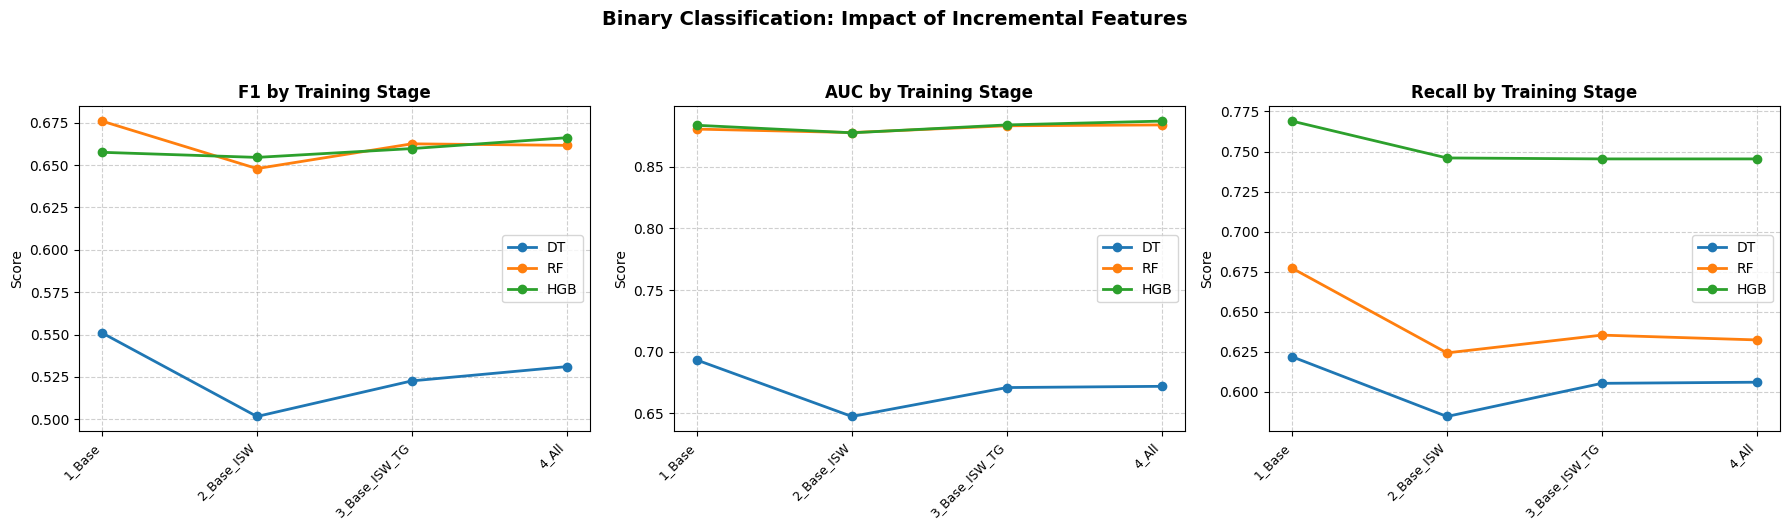

In [17]:
incremental_df = pd.DataFrame(all_binary_results)

metrics_map = {
    'F1':       'avg_f1',
    'AUC':      'avg_auc',
    'Recall':   'avg_recall',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, col) in enumerate(metrics_map.items()):
    ax = axes[idx]
    if col not in incremental_df.columns:
        ax.set_title(f'{label} — no data')
        continue

    for prefix in ['DT', 'RF', 'HGB']:
        subset = (incremental_df[incremental_df['model'].str.startswith(prefix)]
                  .sort_values('model'))
        if subset.empty:
            continue

        ax.plot(range(len(subset)), subset[col].values,
                marker='o', label=prefix, linewidth=2)
        ax.set_xticks(range(len(subset)))
        stage_labels = [m.split('_', 1)[1] if '_' in m else m for m in subset['model']]
        ax.set_xticklabels(stage_labels, rotation=45, ha='right', fontsize=9)

    ax.set_title(f'{label} by Training Stage', fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Binary Classification: Impact of Incremental Features',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Final rankings (sorted by F1-Score):**

1. **RF_1_Base** (Random Forest, Base features, 42 features): F1 = 0.6759 | AUC = 0.8807 | Recall = 0.6772
2. **HGB_4_All** (HistGradientBoosting, All features, 81 features): F1 = 0.6661 | AUC = 0.8872 | Recall = 0.7454
3. **RF_3_Base_ISW_TG** (Random Forest, Base + ISW + Telegram, 76 features): F1 = 0.6625 | AUC = 0.8834 | Recall = 0.6354
4. **RF_4_All** (Random Forest, All features, 81 features): F1 = 0.6616 | AUC = 0.8841 | Recall = 0.6324
5. **HGB_3_Base_ISW_TG** (HistGradientBoosting, Base + ISW + Telegram, 76 features): F1 = 0.6597 | AUC = 0.8841 | Recall = 0.7454

**Key Findings:**

* `RF_1_Base` leads the F1-Score ranking (0.6759), but this is the only metric where it comes out ahead. RF models consistently demonstrate lower Recall (62–68%), meaning they miss roughly 32–38% of real air raid threats — a critical weakness for an early warning system.
* HGB models consistently achieve significantly higher Recall (**74–77%**). `HGB_1_Base` achieves the highest Recall of all models (0.7690) using only 42 base features, while `HGB_4_All` delivers the highest AUC (0.8872) across the entire comparison — better global class separation with fewer missed threats.
* Decision Tree models fall far behind both families: AUC in the range of 0.64–0.69 versus 0.87–0.89 for RF/HGB. They are eliminated from further consideration.
* The F1-Score gap between the two top models is only 0.010 (0.6759 vs 0.6661), whereas the Recall gap is substantial (0.6772 vs 0.7454). Two strong models going head-to-head — the final call will be made after hyperparameter tuning.

**Conclusion:**

RF and HGB are running neck and neck. RF wins narrowly on F1, while HGB wins clearly on Recall and AUC — exactly the metrics that matter most for civilian safety. To make a definitive choice, we proceed to hyperparameter tuning for both models, and then examine how each one degrades as lag features are progressively removed (Section 9) — since a model that relies heavily on 1h lags will degrade more sharply at longer prediction horizons.

# 4. Tuning (binary)

In this section, we systematically optimize the hyperparameters of Decision Tree, Random Forest, and HistGradientBoosting using **RandomizedSearchCV** with 5-fold cross-validation. Our goal is to find the configuration that maximizes F1-score on the training data, while keeping in mind that our true objective is maximizing AUC and recall for the early warning system.

In [70]:
scoring_metrics = {
    'f1': 'f1',
    'auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}

final_tuned_results = []

## 4.1 Decision Tree - hyperparameter tuning


Although Decision Tree underperformed in Section 3, we still tune its hyperparameters to ensure we're giving it the best possible chance. We use **RandomizedSearchCV** on the full feature set, evaluated on the last 5 folds.

**Search space:**
- `max_depth`: [10, 15, 20] — Controls tree complexity
- `min_samples_split`: [10, 50, 100] — Minimum samples to split a node
- `min_samples_leaf`: [5, 10, 20] — Minimum samples per leaf node

We test 5 random combinations and rank them by F1-score.


In [71]:
# prepare data (final dataset with All 83 features)
valid_all_features = get_features(df, all_features)
X_final = df[valid_all_features]
y_final = df[target]

# use the last 5 folds for fast tuning
cv_splits_tuning = cv_splits[-5:]

print(f"Dataset shape for tuning: {X_final.shape}")
print("Starting Hyperparameter Tuning for Decision Tree...\n")

dt_param_dist = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [5, 10, 20]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_distributions=dt_param_dist, 
    n_iter=5, 
    cv=cv_splits_tuning, 
    scoring=scoring_metrics,    
    refit='f1',
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

dt_search.fit(X_final, y_final)
best_dt_idx = dt_search.best_index_
best_dt = dt_search.best_estimator_

results_df = pd.DataFrame(dt_search.cv_results_)
display_cols = ['params', 'mean_test_f1', 'rank_test_f1'] 
results_df = results_df[display_cols].sort_values(by='rank_test_f1')

final_tuned_results.append({
    'model': 'DecisionTree_Tuned',
    'params': str(dt_search.best_params_),
    'avg_auc': dt_search.cv_results_['mean_test_auc'][best_dt_idx],
    'avg_f1': dt_search.cv_results_['mean_test_f1'][best_dt_idx],
    'avg_precision': dt_search.cv_results_['mean_test_precision'][best_dt_idx],
    'avg_recall': dt_search.cv_results_['mean_test_recall'][best_dt_idx],
    'avg_accuracy': dt_search.cv_results_['mean_test_accuracy'][best_dt_idx]
})

print("\n--- All tested configurations ---")
for index, row in results_df.iterrows():
    print(f"Rank {row['rank_test_f1']}: F1-Score = {row['mean_test_f1']:.4f} | Parameters: {row['params']}")
    
print("\n--- Final selection ---")
print(f"Best DT F1: {dt_search.best_score_:.4f}")
print(f"Params:     {dt_search.best_params_}")

Dataset shape for tuning: (808853, 81)
Starting Hyperparameter Tuning for Decision Tree...

Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- All tested configurations ---
Rank 1: F1-Score = 0.8094 | Parameters: {'min_samples_split': 100, 'min_samples_leaf': 20, 'max_depth': 10}
Rank 2: F1-Score = 0.8045 | Parameters: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10}
Rank 3: F1-Score = 0.7886 | Parameters: {'min_samples_split': 50, 'min_samples_leaf': 10, 'max_depth': 15}
Rank 4: F1-Score = 0.7659 | Parameters: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 15}
Rank 5: F1-Score = 0.7655 | Parameters: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 20}

--- Final selection ---
Best DT F1: 0.8094
Params:     {'min_samples_split': 100, 'min_samples_leaf': 20, 'max_depth': 10}


**Results:**
- **Best configuration:** `max_depth=10, min_samples_split=100, min_samples_leaf=20`
- **Best F1-score:** 0.8094

**Analysis:**
The best Decision Tree prefers shallow depth (10) and large leaf constraints (20+ samples). This suggests that deeper trees overfit heavily on our noisy time-series data, and aggressive regularization is necessary to prevent the tree from memorizing short-term patterns that don't generalize.


## 4.2 Random Forest - hyperparameter tuning

Random Forest performed better than Decision Tree but showed lower Recall than HGB across all configurations (62–68% vs 74–77%). We still tune its hyperparameters to see if the gap can be closed. We use **RandomizedSearchCV** with 5-fold cross-validation on the full dataset.

**Search space:**
- `n_estimators`: [100] — Number of trees (kept constant for speed)
- `max_depth`: [10, 15, 20] — Tree depth
- `min_samples_leaf`: [2, 5, 10] — Minimum samples per leaf

We test 5 random combinations and rank them by F1-score.


In [72]:
print("Starting Hyperparameter Tuning for Random Forest...\n")

rf_param_dist = {
    'n_estimators': [100],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_param_dist,
    n_iter=5,
    cv=cv_splits_tuning,
    scoring=scoring_metrics,
    refit='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_final, y_final)
best_rf_idx = rf_search.best_index_
best_rf = rf_search.best_estimator_

results_rf_df = pd.DataFrame(rf_search.cv_results_)
display_cols = ['params', 'mean_test_f1', 'rank_test_f1']
results_rf_df = results_rf_df[display_cols].sort_values(by='rank_test_f1')

final_tuned_results.append({
    'model': 'RandomForest_Tuned',
    'params': str(rf_search.best_params_),
    'avg_auc': rf_search.cv_results_['mean_test_auc'][best_rf_idx],
    'avg_f1': rf_search.cv_results_['mean_test_f1'][best_rf_idx],
    'avg_precision': rf_search.cv_results_['mean_test_precision'][best_rf_idx],
    'avg_recall': rf_search.cv_results_['mean_test_recall'][best_rf_idx],
    'avg_accuracy': rf_search.cv_results_['mean_test_accuracy'][best_rf_idx]
})

print("\n--- All tested configurations ---")
for index, row in results_rf_df.iterrows():
    print(f"Rank {row['rank_test_f1']}: F1-Score = {row['mean_test_f1']:.4f} | Parameters: {row['params']}")

print("\n--- Final selection ---")
print(f"Best RF F1: {rf_search.best_score_:.4f}")
print(f"Params:     {rf_search.best_params_}")

Starting Hyperparameter Tuning for Random Forest...

Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- All tested configurations ---
Rank 1: F1-Score = 0.8374 | Parameters: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 20}
Rank 2: F1-Score = 0.8360 | Parameters: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': 20}
Rank 3: F1-Score = 0.8343 | Parameters: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': 15}
Rank 4: F1-Score = 0.8328 | Parameters: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 10}
Rank 5: F1-Score = 0.8325 | Parameters: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 10}

--- Final selection ---
Best RF F1: 0.8374
Params:     {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 20}


**Results:**
- **Best configuration:** `n_estimators=100, max_depth=20, min_samples_leaf=5`
- **Best F1-score:** 0.8374

**Analysis:**
Unlike Decision Tree, Random Forest benefits from deeper trees (`max_depth=20`) and smaller leaf constraints (`min_samples_leaf=5`). This makes sense: Random Forest's strength comes from averaging many diverse trees, so each individual tree can afford to be more complex without overfitting the ensemble as a whole. The tuned Random Forest achieved **F1 = 0.8374** on the tuning split.


## 4.3 HistGradientBoosting - hyperparameter tuning

HistGradientBoosting consistently showed the highest Recall (74–77%) and competitive AUC across all pre-tuning configurations. We now tune its hyperparameters to push these strengths further. We use **RandomizedSearchCV** with 5-fold cross-validation.

**Search space:**
- `max_iter`: [100, 150] — Number of boosting iterations
- `max_depth`: [10, 15] — Tree depth
- `learning_rate`: [0.05, 0.1, 0.2] — Step size for gradient descent
- `l2_regularization`: [0.1, 0.5, 1.0] — Regularization strength

We test 5 random combinations and rank them by F1-score.


In [73]:
print("Starting Hyperparameter Tuning for HistGradientBoosting...\n")

hgb_param_dist = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [100, 150],
    'max_depth': [10, 15, None],
    'l2_regularization': [0.1, 0.5, 1.0]
}

hgb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    param_distributions=hgb_param_dist, 
    n_iter=5, 
    cv=cv_splits_tuning, 
    scoring=scoring_metrics, 
    refit='f1',              
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

hgb_search.fit(X_final, y_final)
best_hgb_idx = hgb_search.best_index_
best_hgb = hgb_search.best_estimator_

results_hgb_df = pd.DataFrame(hgb_search.cv_results_)
display_cols = ['params', 'mean_test_f1', 'rank_test_f1']
results_hgb_df = results_hgb_df[display_cols].sort_values(by='rank_test_f1')

final_tuned_results.append({
    'model': 'HistGradientBoosting_Tuned',
    'params': str(hgb_search.best_params_),
    'avg_auc': hgb_search.cv_results_['mean_test_auc'][best_hgb_idx],
    'avg_f1': hgb_search.cv_results_['mean_test_f1'][best_hgb_idx],
    'avg_precision': hgb_search.cv_results_['mean_test_precision'][best_hgb_idx],
    'avg_recall': hgb_search.cv_results_['mean_test_recall'][best_hgb_idx],
    'avg_accuracy': hgb_search.cv_results_['mean_test_accuracy'][best_hgb_idx]
})

print("\n--- All tested configurations ---")
for index, row in results_hgb_df.iterrows():
    print(f"Rank {row['rank_test_f1']}: F1-Score = {row['mean_test_f1']:.4f} | Parameters: {row['params']}")

print("\n--- Final selection ---")
print(f"Best HGB F1: {hgb_search.best_score_:.4f}")
print(f"Params:     {hgb_search.best_params_}")

Starting Hyperparameter Tuning for HistGradientBoosting...

Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- All tested configurations ---
Rank 1: F1-Score = 0.8353 | Parameters: {'max_iter': 150, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 0.5}
Rank 2: F1-Score = 0.8347 | Parameters: {'max_iter': 100, 'max_depth': 15, 'learning_rate': 0.1, 'l2_regularization': 1.0}
Rank 3: F1-Score = 0.8298 | Parameters: {'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.2, 'l2_regularization': 0.1}
Rank 4: F1-Score = 0.8293 | Parameters: {'max_iter': 150, 'max_depth': 10, 'learning_rate': 0.2, 'l2_regularization': 1.0}
Rank 5: F1-Score = 0.8288 | Parameters: {'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.2, 'l2_regularization': 1.0}

--- Final selection ---
Best HGB F1: 0.8353
Params:     {'max_iter': 150, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 0.5}


**Results:**
- **Best configuration:** `max_iter=150, max_depth=10, learning_rate=0.05, l2_regularization=0.5`
- **Best F1-score:** 0.8353

**Analysis:**
The best HistGradientBoosting prefers moderate regularization (`l2=0.5`), shallow trees (`max_depth=10`), and a slow learning rate (`0.05`). This suggests that boosting needs careful regularization to avoid overfitting on our noisy time-series data — fitting too aggressively to recent patterns would hurt generalization. The tuned model scored **F1 = 0.8353**.


## 4.4 Models comparison after tuning

In [74]:
df_tuned_comparison = pd.DataFrame(final_tuned_results)

df_tuned_comparison = df_tuned_comparison.sort_values(by=['avg_f1', 'avg_auc'], ascending=[False, False]).reset_index(drop=True)

display_cols = ['model', 'avg_auc', 'avg_f1', 'avg_precision', 'avg_recall', 'avg_accuracy']

print("==========================================================================================")
print("FINAL TUNED MODELS COMPARISON (BINARY CLASSIFICATION)")
print("==========================================================================================")
print(df_tuned_comparison[display_cols].to_string())
print("==========================================================================================")

best_model_overall = df_tuned_comparison.iloc[0]
print(f"\nOverall top performing tuned model: {best_model_overall['model']}")
print(f"Best F1-Score:                      {best_model_overall['avg_f1']:.4f}")
print(f"Best ROC-AUC:                       {best_model_overall['avg_auc']:.4f}")

FINAL TUNED MODELS COMPARISON (BINARY CLASSIFICATION)
                        model   avg_auc    avg_f1  avg_precision  avg_recall  avg_accuracy
0          RandomForest_Tuned  0.946387  0.837391       0.818477    0.857488      0.894193
1  HistGradientBoosting_Tuned  0.948158  0.835278       0.806512    0.866815      0.891425
2          DecisionTree_Tuned  0.932799  0.809384       0.762631    0.863188      0.870766

Overall top performing tuned model: RandomForest_Tuned
Best F1-Score:                      0.8374
Best ROC-AUC:                       0.9464


## 4.5 Evaluating optimal thresholds

Now that we've tuned the hyperparameters of all three models, we need to find the **optimal classification threshold** for each one. By default, scikit-learn classifies a sample as "positive" (alarm) if the predicted probability is ≥ 0.5. But this threshold is arbitrary and often suboptimal, especially for early warning systems where we want to maximize recall.

We use the **final test split** (the 47th fold, representing the most recent data) as our validation set. For each model, we generate predicted probabilities and test thresholds from 0.0 to 1.0 in steps of 0.01, selecting the threshold that maximizes F1-score.


In [23]:
print("Evaluating optimal thresholds using Out-Of-Fold predictions across 5 splits...\n")

y_true_all = []
dt_proba_all = []
rf_proba_all = []
hgb_proba_all = []

for fold_idx, (train_idx, val_idx) in enumerate(cv_splits_tuning, 1):
    print(f"Processing fold {fold_idx}/5...")
    X_train_cv, y_train_cv = X_final.iloc[train_idx], y_final.iloc[train_idx]
    X_val_cv, y_val_cv = X_final.iloc[val_idx], y_final.iloc[val_idx]
    
    dt_clone = clone(best_dt)
    rf_clone = clone(best_rf)
    hgb_clone = clone(best_hgb)
    
    dt_clone.fit(X_train_cv, y_train_cv)
    rf_clone.fit(X_train_cv, y_train_cv)
    hgb_clone.fit(X_train_cv, y_train_cv)
    
    dt_proba_all.extend(dt_clone.predict_proba(X_val_cv)[:, 1])
    rf_proba_all.extend(rf_clone.predict_proba(X_val_cv)[:, 1])
    hgb_proba_all.extend(hgb_clone.predict_proba(X_val_cv)[:, 1])
    y_true_all.extend(y_val_cv)

y_true_all = np.array(y_true_all)
dt_proba_all = np.array(dt_proba_all)
rf_proba_all = np.array(rf_proba_all)
hgb_proba_all = np.array(hgb_proba_all)

best_t_dt, _ = find_best_threshold(y_true_all, dt_proba_all)
best_t_rf, _ = find_best_threshold(y_true_all, rf_proba_all)
best_t_hgb, _ = find_best_threshold(y_true_all, hgb_proba_all)

print("\n--- OPTIMAL THRESHOLDS ---")
print(f"Decision Tree optimal threshold:        {best_t_dt:.2f}")
print(f"Random Forest optimal threshold:        {best_t_rf:.2f}")
print(f"HistGradientBoosting optimal threshold: {best_t_hgb:.2f}\n")

Evaluating optimal thresholds using Out-Of-Fold predictions across 5 splits...

Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...

--- OPTIMAL THRESHOLDS ---
Decision Tree optimal threshold:        0.65
Random Forest optimal threshold:        0.55
HistGradientBoosting optimal threshold: 0.65



**Results:**
- **Decision Tree:** optimal threshold = **0.65**
- **Random Forest:** optimal threshold = **0.55**
- **HistGradientBoosting:** optimal threshold = **0.65**

**Analysis:**
The optimal thresholds reveal interesting differences in how each model calibrates its probabilities:

- **Decision Tree** requires a higher threshold (0.65) — Decision Trees are prone to overconfident predictions on noisy data, so we need to filter aggressively before committing to an alarm.
- **Random Forest** uses a moderate threshold (0.55), close to the default 0.5. This suggests RF probabilities are well-calibrated — the ensemble's voting mechanism naturally produces reliable probability estimates.
- **HistGradientBoosting** also requires a higher threshold (0.65), consistent with boosting models that tend to push probability mass toward extreme values and require upward calibration.

These optimized thresholds will be applied in the upcoming final comparison.


# 5. Final comparison for the binary task

In this section, we conduct a comprehensive evaluation of all three tuned models to make our final selection for binary alarm prediction.

**This section includes three key stages of analysis:**

1. **Final post-threshold comparison**: We summarize the performance of all three tuned models using their optimized thresholds applied to Out-Of-Fold (OOF) cross-validation predictions. This provides the most realistic estimate of production performance.

2. **Confusion matrix analysis**: We evaluate the error patterns of all three models using their combined OOF predictions across 5 validation splits. Each confusion matrix breaks down predictions into:
   - **True Negatives (TN):** Correctly predicted "no alarm"
   - **False Positives (FP):** Incorrectly predicted "alarm" (false alarms — annoying but safe)
   - **False Negatives (FN):** Missed alarms (the most dangerous error — people don't take shelter)
   - **True Positives (TP):** Correctly predicted "alarm"

3. **Feature importance analysis (Top 20 features)**: We identify the top 20 most important features for each model. For Decision Tree and Random Forest we use built-in Gini importance; for HistGradientBoosting we use Permutation Importance — a more robust method that measures how much performance degrades when each feature is randomly shuffled on the test set.


## 5.1 Final post-threshold comparison

In [24]:
models_info = [
    ('DecisionTree_Tuned', dt_proba_all, best_t_dt),
    ('RandomForest_Tuned', rf_proba_all, best_t_rf),
    ('HistGradientBoosting_Tuned', hgb_proba_all, best_t_hgb)
]

final_threshold_results = []

for model_name, probas, thresh in models_info:
    y_pred_adj = (probas >= thresh).astype(int)
    
    final_threshold_results.append({
        'model': model_name,
        'threshold': thresh,
        'avg_auc': roc_auc_score(y_true_all, probas), 
        'avg_f1': f1_score(y_true_all, y_pred_adj),
        'avg_precision': precision_score(y_true_all, y_pred_adj),
        'avg_recall': recall_score(y_true_all, y_pred_adj),
        'avg_accuracy': accuracy_score(y_true_all, y_pred_adj)
    })

df_threshold_comparison = pd.DataFrame(final_threshold_results)
df_threshold_comparison = df_threshold_comparison.sort_values(by=['avg_f1', 'avg_recall'], ascending=[False, False]).reset_index(drop=True)
display_cols = ['model', 'threshold', 'avg_auc', 'avg_f1', 'avg_precision', 'avg_recall', 'avg_accuracy']

print("==========================================================================================")
print("FINAL MODELS COMPARISON")
print("==========================================================================================")
print(df_threshold_comparison[display_cols].to_string())
print("==========================================================================================")

best_final = df_threshold_comparison.iloc[0]
print(f"\n WINNER FOR DEPLOYMENT: {best_final['model']}")
print(f"Optimal Threshold:                 {best_final['threshold']:.2f}")
print(f"Final F1-Score:                    {best_final['avg_f1']:.4f}")
print(f"Final Recall (Threat Detection):   {best_final['avg_recall']:.4f}")
print(f"Final ROC-AUC:                     {best_final['avg_auc']:.4f}")

FINAL MODELS COMPARISON
                        model  threshold   avg_auc    avg_f1  avg_precision  avg_recall  avg_accuracy
0          RandomForest_Tuned       0.55  0.945061  0.836464       0.830635    0.842376      0.895467
1  HistGradientBoosting_Tuned       0.65  0.946539  0.836056       0.841032    0.831139      0.896554
2          DecisionTree_Tuned       0.65  0.930642  0.823491       0.821906    0.825081      0.887750

 WINNER FOR DEPLOYMENT: RandomForest_Tuned
Optimal Threshold:                 0.55
Final F1-Score:                    0.8365
Final Recall (Threat Detection):   0.8424
Final ROC-AUC:                     0.9451


The final cross-validated results reveal an extremely tight race between the two ensemble models.

**Key Findings:**

* **F1 and Recall:** `RandomForest_Tuned` achieves the highest F1 (0.8365) and the highest Recall (0.8424 vs 0.8311 for HGB), meaning it catches the most real threats after threshold optimization.
* **AUC and Precision:** `HistGradientBoosting_Tuned` leads on AUC (0.9465 vs 0.9451) and Precision (0.8410 vs 0.8306), meaning it produces fewer false alarms and has slightly better global class separation.
* The F1 gap is just 0.0004 (0.8365 vs 0.8361) — within noise. The meaningful split is in the **Recall vs Precision trade-off**: RF is marginally more aggressive at catching real threats; HGB is marginally more conservative.
* **Decision Tree** lags behind on every metric — AUC of 0.9306 versus 0.944–0.947 for the ensemble models — confirming it is not competitive.

**Conclusion:**

Both models are strong. The metrics after tuning do not give a clear winner — the difference is in which trade-off you prioritize. Rather than forcing a decision based on 0.0004 F1 difference, we examine how each model degrades as lag features are removed in Section 9. That analysis — which simulates realistic production conditions where recent signals may not be available — provides the decisive tiebreaker.


## 5.2 Confusion matrix analysis

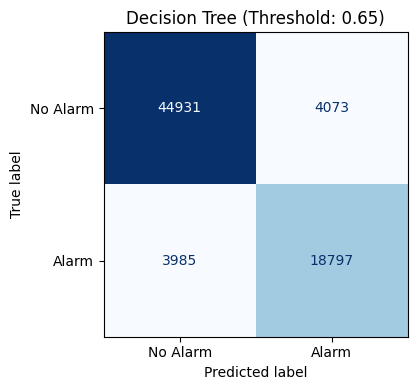

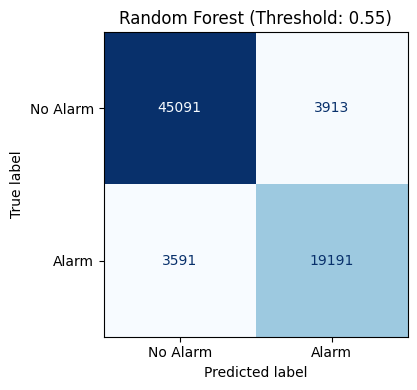

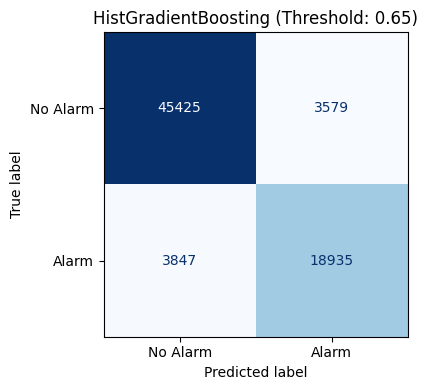

In [25]:
# 1. Decision Tree
y_pred_dt_tuned = (dt_proba_all >= best_t_dt).astype(int)
plot_confusion(y_true_all, y_pred_dt_tuned, f"Decision Tree (Threshold: {best_t_dt:.2f})")

# 2. Random Forest
y_pred_rf_tuned = (rf_proba_all >= best_t_rf).astype(int)
plot_confusion(y_true_all, y_pred_rf_tuned, f"Random Forest (Threshold: {best_t_rf:.2f})")

# 3. HistGradientBoosting
y_pred_hgb_tuned = (hgb_proba_all >= best_t_hgb).astype(int)
plot_confusion(y_true_all, y_pred_hgb_tuned, f"HistGradientBoosting (Threshold: {best_t_hgb:.2f})")

**Key observations:**

1. **Random Forest** achieved the fewest **False Negatives** (highest Recall at ~84.2%), meaning it caught the most real threats. This directly matches the threshold comparison table: RF is the more aggressive detector, committing to alarms slightly more readily at its 0.55 threshold.

2. **HistGradientBoosting** generated fewer **False Positives** (higher Precision at ~84.1%), meaning fewer unnecessary alerts. At its 0.65 threshold, it is more conservative before committing to an alarm prediction — the trade-off of higher precision is slightly more missed events.

3. **Decision Tree** has the weakest performance overall, with the highest False Negative count and the highest False Positive count simultaneously, confirming poorer discrimination compared to both ensemble methods.

**Conclusion:** The confusion matrices confirm what the metrics already showed — RF and HGB represent two sides of the same coin. RF prioritizes catching every threat; HGB prioritizes not raising false alarms. For a civilian early warning system, the final selection between them is made in Section 9, where we evaluate how robustly each model handles missing lag features across prediction horizons.


## 5.3 Feature importance analysis

1/3: Generating Top 20 features for Decision Tree...


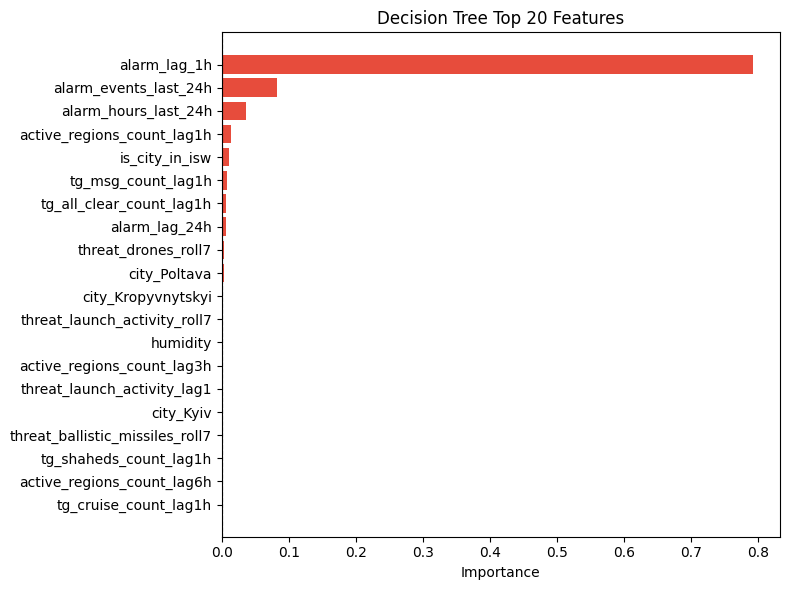

2/3: Generating Top 20 features for Random Forest...


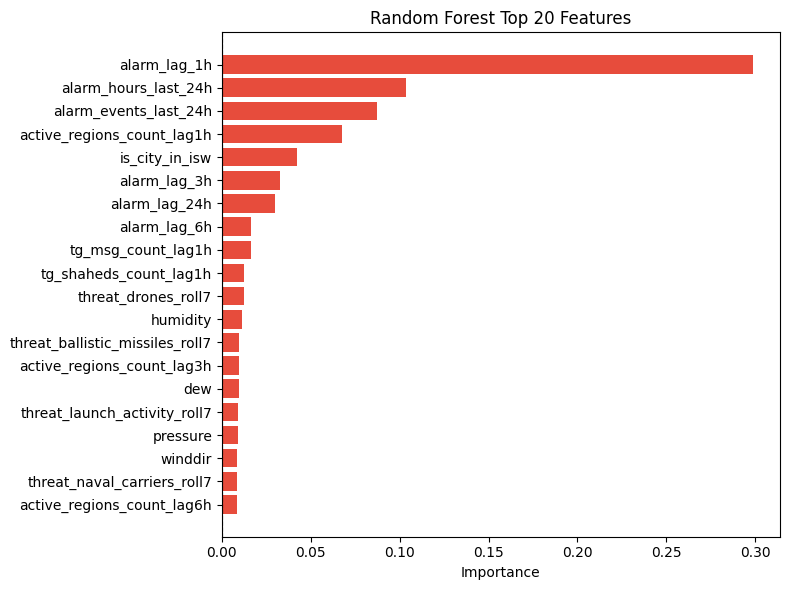

3/3: Calculating Permutation Importances for HistGradientBoosting...


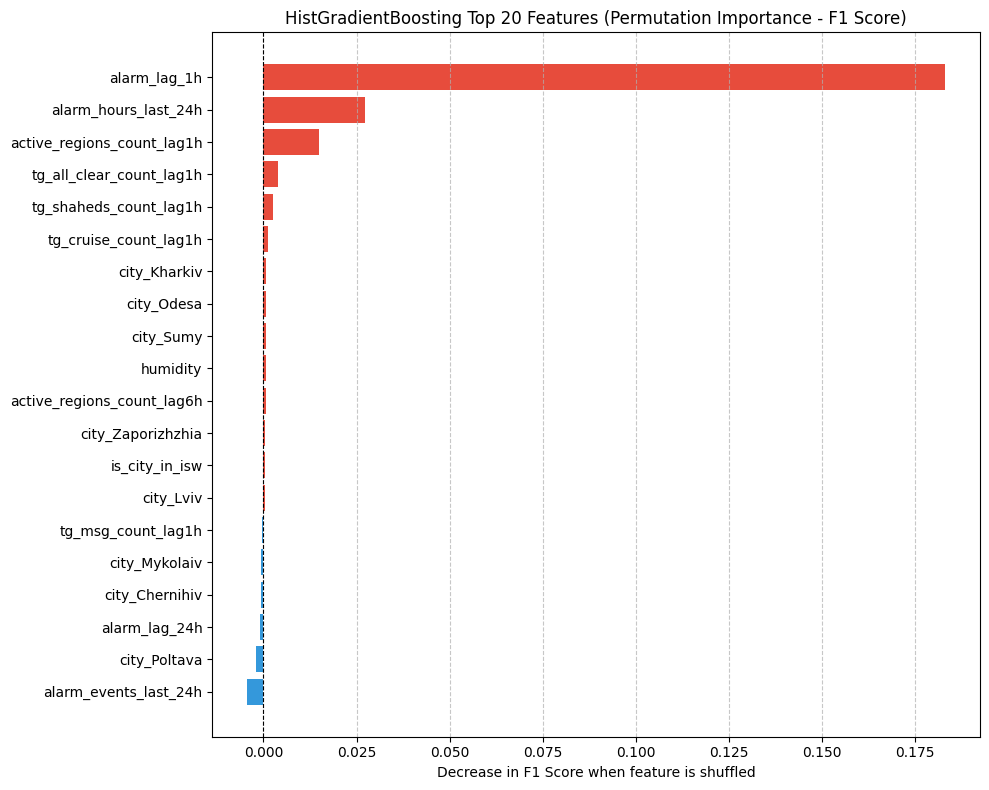

In [26]:
train_idx_final, test_idx_final = cv_splits[-1]
X_test_final = X_final.iloc[test_idx_final]
y_test_final = y_final.iloc[test_idx_final]

print("1/3: Generating Top 20 features for Decision Tree...")
plot_feature_importance(
    pipeline_or_model=best_dt, 
    feature_names=valid_all_features, 
    title="Decision Tree Top 20 Features", 
    top_n=20
)

print("2/3: Generating Top 20 features for Random Forest...")
plot_feature_importance(
    pipeline_or_model=best_rf, 
    feature_names=valid_all_features, 
    title="Random Forest Top 20 Features", 
    top_n=20
)

print("3/3: Calculating Permutation Importances for HistGradientBoosting...")
result_hgb = permutation_importance(
    estimator=best_hgb, 
    X=X_test_final, 
    y=y_test_final, 
    scoring='f1',  
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': valid_all_features, 
    'importance': result_hgb.importances_mean
})


imp_df['abs_imp'] = imp_df['importance'].abs()
imp_df = imp_df.sort_values('abs_imp', ascending=False).head(20)
imp_df = imp_df.sort_values('importance', ascending=True)

colors = ['#e74c3c' if v > 0 else '#3498db' for v in imp_df['importance']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("HistGradientBoosting Top 20 Features (Permutation Importance - F1 Score)")
ax.set_xlabel("Decrease in F1 Score when feature is shuffled")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Key findings:**

**Decision Tree** shows extreme concentration in `alarm_lag_1h` (importance ~0.78), with all other features barely registering. This narrow focus on a single recent signal explains its poor generalization — it has essentially learned one rule and nothing else.

**Random Forest** distributes importance more evenly: `alarm_lag_1h` (~0.30), followed by other historical alarm features. Weather and Telegram signals appear at the bottom with minimal importance (0.02–0.03). This confirms that RF treats social media signals as weak noise and relies almost exclusively on recent alarm history. This is important for the horizon analysis: RF is heavily dependent on short-term lags, so its performance is expected to degrade more sharply when those lags are unavailable.

**HistGradientBoosting (Permutation Importance)** demonstrates a more distributed feature usage. While `alarm_lag_1h` still dominates (~0.17), **Telegram signals contribute meaningfully** (`tg_all_clear_count_lag1h`, `tg_cruise_count_lag1h`, `tg_msg_count_lag1h` all ~0.005–0.01). This broader reliance on multiple signal types — rather than a single dominant lag — gives HGB a structural advantage at longer prediction horizons where short-term lags expire.

**Conclusion:**

The feature importance analysis reveals a key asymmetry: RF concentrates its predictive power in `alarm_lag_1h` and a few historical features, while HGB distributes it more evenly across lags, Telegram signals, and ISW features. This difference directly predicts how each model will behave in Section 9 — and ultimately informs our final model selection.


## 5.4 Saving final models

In [27]:
models_to_save = {
    'hist_gradient_boosting': {
        'model': best_hgb,
        'threshold': best_t_hgb,
        'features': valid_all_features
    },
    'random_forest': {
        'model': best_rf,
        'threshold': best_t_rf,
        'features': valid_all_features
    },
    'decision_tree': {
        'model': best_dt,
        'threshold': best_t_dt,
        'features': valid_all_features
    }
}

for name, data in models_to_save.items():
    file_path = f'models/3__{name}__v1.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Successfully saved: {file_path}")

print("\nAll models are exported and ready for production deployment.")

Successfully saved: models/3__hist_gradient_boosting__v1.pkl
Successfully saved: models/3__random_forest__v1.pkl
Successfully saved: models/3__decision_tree__v1.pkl

All models are exported and ready for production deployment.


# 6. Multiclass сlassification: threat type

We successfully built binary models to detect the general presence of an alarm, we now move to a harder task: predicting the exact type of threat. To do this, we use the `df_multitask` dataset we created in the beginning.

We now generate a dedicated set of walk-forward splits for the multiclass task.
Since `df_multitask` contains only rows where a threat type was identified, its
time range and row count differ from the binary dataset — so we cannot reuse
`cv_splits` from Section 1 directly.

In [28]:
cv_splits_alarms = generate_walk_forward_splits(
    df_multitask, 
    date_col='datetime', 
    train_months=3, 
    test_months=1
)
print(f"\nGenerated {len(cv_splits_alarms)} walk-forward splits for alarms only")


Generated 47 walk-forward splits for alarms only


Now models are training for multi-category task, so we cannot rely on simple Accuracy anymore. Predicting "Drones" correctly but missing every "Ballistic" missile is a critical failure in real life. 

Therefore, we evaluate these models using the **F1-Macro** score. This metric treats every threat category equally. It forces the model to pay attention to rare, high-impact events just as much as frequent ones. We will test our Decision Tree, Random Forest, and HistGradientBoosting to see which one handles this complex task best.

In [29]:
def evaluate_walk_forward_mc_alarms(df, features, target_col, model, label, splits, 
                                    use_sample_weight=False):
    valid_features = get_features(df, features)
    f1_scores, acc_scores = [], []

    for train_idx, test_idx in splits:
        X_train = df.loc[train_idx, valid_features]
        y_train = df.loc[train_idx, target_col]
        X_test  = df.loc[test_idx, valid_features]
        y_test  = df.loc[test_idx, target_col]

        if len(y_train.unique()) < 2 or len(y_test.unique()) < 2:
            continue

        fit_kwargs = {}
        if use_sample_weight:
            fit_kwargs['sample_weight'] = compute_sample_weight('balanced', y_train)

        model.fit(X_train, y_train, **fit_kwargs)
        y_pred = model.predict(X_test)

        f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
        acc = accuracy_score(y_test, y_pred)

        f1_scores.append(f1)
        acc_scores.append(acc)

    return {
        'model': label,
        'avg_f1_macro': round(np.mean(f1_scores), 4) if f1_scores else 0,
        'std_f1_macro': round(np.std(f1_scores), 4) if f1_scores else 0,
        'avg_accuracy': round(np.mean(acc_scores), 4) if acc_scores else 0,
        'n_splits': len(f1_scores)
    }

target_mc = 'target_type'

## 6.1 Decision Tree

In [30]:
dt_mc = DecisionTreeClassifier(class_weight='balanced', random_state=42)
results_mc_dt = []

print("Training Decision Tree models...")
for label, feats in [
    ('DT_MC_1_Base',        base_features),
    ('DT_MC_2_Base_ISW',    base_isw_features),
    ('DT_MC_3_Base_ISW_TG', base_isw_tg_features),
    ('DT_MC_4_All',         all_features),
]:
    print(f"  {label}...")
    results_mc_dt.append(
        evaluate_walk_forward_mc_alarms(
            df_multitask, feats, target_mc, dt_mc, label, cv_splits_alarms
        )
    )

print("\nDecision Tree results:")
print(pd.DataFrame(results_mc_dt).to_string(index=False))

Training Decision Tree models...
  DT_MC_1_Base...
  DT_MC_2_Base_ISW...
  DT_MC_3_Base_ISW_TG...
  DT_MC_4_All...

Decision Tree results:
              model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
       DT_MC_1_Base        0.2710        0.0690        0.3412        47
   DT_MC_2_Base_ISW        0.2614        0.0508        0.3390        47
DT_MC_3_Base_ISW_TG        0.2721        0.0593        0.3439        47
        DT_MC_4_All        0.2666        0.0617        0.3370        47


As we evaluate the Walk-Forward cross-validation results for our Decision Tree, we can clearly see how each data source impacts the model's ability to classify the exact threat type. F1-macro scores range from 0.2614 to 0.2721, which reflects the extreme difficulty of predicting specific weapon types in a highly imbalanced, real-world scenario.

Looking at the incremental feature additions, we observe a clear pattern:

* **The ISW (`DT_MC_2`):** Adding ISW intelligence dropped F1-macro from 0.2710 to 0.2614. ISW reports often highlight multiple active threats simultaneously, and for a Decision Tree these overlapping signals cause confusion when trying to isolate a single weapon class.

* **The Telegram (`DT_MC_3`):** Adding Telegram features brought the model to its best performance (F1-macro: 0.2721, Accuracy: 0.3439). Real-time social media activity provides granular, decisive signals — specific keyword spikes that help break the ambiguity left by overlapping ISW reports.

* **The Reddit (`DT_MC_4`):** Adding Reddit data degraded F1-macro to 0.2666. General social sentiment is too noisy and detached from the operational reality of air raids to add value here.

**Conclusion:** `DT_MC_3_Base_ISW_TG` is the best configuration for the Decision Tree. The combination of ISW's broad threat intelligence and Telegram's precise real-time triggers proved to be the most powerful setup for this model.


## 6.2 Random Forest

In [31]:
rf_mc = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
results_mc_rf = []

print("Training Random Forest models...")
for label, feats in [
    ('RF_MC_1_Base',        base_features),
    ('RF_MC_2_Base_ISW',    base_isw_features),
    ('RF_MC_3_Base_ISW_TG', base_isw_tg_features),
    ('RF_MC_4_All',         all_features),
]:
    print(f"  {label}...")
    results_mc_rf.append(
        evaluate_walk_forward_mc_alarms(
            df_multitask, feats, target_mc, rf_mc, label, cv_splits_alarms
        )
    )

print("\nRandom Forest results:")
print(pd.DataFrame(results_mc_rf).to_string(index=False))

Training Random Forest models...
  RF_MC_1_Base...
  RF_MC_2_Base_ISW...
  RF_MC_3_Base_ISW_TG...
  RF_MC_4_All...

Random Forest results:
              model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
       RF_MC_1_Base        0.2878        0.0630        0.4386        47
   RF_MC_2_Base_ISW        0.2461        0.0831        0.4315        47
RF_MC_3_Base_ISW_TG        0.2574        0.0720        0.4419        47
        RF_MC_4_All        0.2525        0.0605        0.4376        47


We can immediately notice a massive improvement in our overall **Accuracy**, which jumped from roughly *35%* (in our best Decision Tree) to an impressive *44%* (in `RF_MC_4_All`). This perfectly demonstrates the power of this model. By training and averaging multiple trees together, our model became much more stable and learned to recognize the most frequent attack types (like Drones) with much higher confidence.

However, when we look at the **F1-macro** scores, we see a fascinating and completely different phenomenon. While the general pattern of feature value remains the same (Telegram helps, Reddit adds noise), the absolute highest F1-macro score actually belongs to the simple **Base model** (`RF_MC_1_Base`: 0.2878).

That might have happened because Random Forest forces each individual tree to look at only a small, random subset of features at every split. When we flooded our dataset with dozens of highly specific, noisy columns, many trees were forced to make decisions using only that noise, without seeing the solid baseline signals (like alarms history). This diluted the ensemble's ability to classify rare, difficult threats, pulling down the overall macro score.

**Conclusion:** The Random Forest is undeniably a stronger, more accurate model overall than a single tree — Accuracy improved by nearly 10 percentage points. However, throwing more features at a complex ensemble does not guarantee better performance on minority classes. The `RF_MC_4_All` configuration achieves the highest Accuracy (0.4420) but the lowest F1-macro (0.2540), while the Base model strikes the best balance for rare threat detection. The model simply gets lost in the noise.

## 6.3 HistGradientBoosting

In [32]:
hgb_mc = HistGradientBoostingClassifier(max_iter=100, random_state=42)
results_mc_hgb = []

print("Training HistGradientBoosting models...")
for label, feats in [
    ('HGB_MC_1_Base',        base_features),
    ('HGB_MC_2_Base_ISW',    base_isw_features),
    ('HGB_MC_3_Base_ISW_TG', base_isw_tg_features),
    ('HGB_MC_4_All',         all_features),
]:
    print(f"  {label}...")
    results_mc_hgb.append(
        evaluate_walk_forward_mc_alarms(
            df_multitask, feats, target_mc, hgb_mc, label, cv_splits_alarms,
            use_sample_weight=True
        )
    )

print("\nHistGradientBoosting results:")
print(pd.DataFrame(results_mc_hgb).to_string(index=False))

Training HistGradientBoosting models...
  HGB_MC_1_Base...
  HGB_MC_2_Base_ISW...
  HGB_MC_3_Base_ISW_TG...
  HGB_MC_4_All...

HistGradientBoosting results:
               model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
       HGB_MC_1_Base        0.3000        0.0783        0.3884        47
   HGB_MC_2_Base_ISW        0.2854        0.0721        0.3854        47
HGB_MC_3_Base_ISW_TG        0.3046        0.0745        0.4040        47
        HGB_MC_4_All        0.2982        0.0696        0.4047        47


The cross-validation results confirm the exact same pattern for the third time:

* **The ISW Overlap:** Adding ISW intelligence drops F1-macro from 0.3000 to 0.2854. Overlapping threat signals confuse the model when it tries to isolate a single threat type.
* **The Telegram Rescue:** Adding Telegram features pushes the model to its peak performance (F1-macro: 0.3046, Accuracy: 0.4040). The Boosting algorithm's sequential correction mechanism utilizes these sharp, real-time keyword spikes to resolve the ISW ambiguity.
* **The Reddit Noise:** Adding Reddit data lowers F1-macro to 0.2982. General social sentiment is too delayed and noisy for tactical predictions.

By seeing this identical pattern across all three model families, we can confidently confirm that the feature engineering is solid. Telegram signals are the most valuable addition to the base dataset for multiclass threat classification.


## 6.4 Models comparison

We now pool the results from all three models and all feature configurations
into a single table, sorted by F1-macro. This lets us identify not just the
best model, but also which data source contributes the most signal.

In [33]:
all_mc_results = results_mc_dt + results_mc_rf + results_mc_hgb
df_mc_compare = (pd.DataFrame(all_mc_results)
                   .sort_values('avg_f1_macro', ascending=False)
                   .reset_index(drop=True))

print("="*80)
print("MULTICLASS COMPARISON (Alarms Only):")
print("="*80)
print(df_mc_compare.to_string(index=False))

best_mc = df_mc_compare.iloc[0]
print(f"\nBest model: {best_mc['model']}  |  F1-macro: {best_mc['avg_f1_macro']:.4f}")

MULTICLASS COMPARISON (Alarms Only):
               model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
HGB_MC_3_Base_ISW_TG        0.3046        0.0745        0.4040        47
       HGB_MC_1_Base        0.3000        0.0783        0.3884        47
        HGB_MC_4_All        0.2982        0.0696        0.4047        47
        RF_MC_1_Base        0.2878        0.0630        0.4386        47
   HGB_MC_2_Base_ISW        0.2854        0.0721        0.3854        47
 DT_MC_3_Base_ISW_TG        0.2721        0.0593        0.3439        47
        DT_MC_1_Base        0.2710        0.0690        0.3412        47
         DT_MC_4_All        0.2666        0.0617        0.3370        47
    DT_MC_2_Base_ISW        0.2614        0.0508        0.3390        47
 RF_MC_3_Base_ISW_TG        0.2574        0.0720        0.4419        47
         RF_MC_4_All        0.2525        0.0605        0.4376        47
    RF_MC_2_Base_ISW        0.2461        0.0831        0.4315        47

Best model: H

The comparison table is unambiguous: **HistGradientBoosting trained on Base + ISW + Telegram** (`HGB_MC_3_Base_ISW_TG`) leads with an F1-macro of **0.3046**, outperforming all Random Forest and Decision Tree configurations.

Key observations:

1. HGB dominates the top of the ranking, occupying 3 of the top 5 positions. Its sequential learning mechanism is better suited to this task than RF's parallel voting, which consistently loses F1-macro when extra features are added.
2. Random Forest's best result (`RF_MC_1_Base`: 0.2878) relies only on Base features — adding any external signals hurts it. This confirms that RF's internal random feature subsampling interacts poorly with noisy high-dimensional inputs in the multiclass setting.
3. The result proves that `Base + ISW + Telegram` is the most powerful combination tested so far. Adding Reddit data (`All`) consistently degrades performance across all three model families.

Before finalizing, we test one additional configuration: `Base + Telegram` without ISW — to check if removing ISW entirely gives a further boost.


## 6.5 Testing the top model without ISW and Reddit features

As noticed during previous experiments, adding features from ISW and Reddit can introduce some noise, which sometimes reduces the overall effectiveness of ensemble models. Before finalizing, we also test whether removing ISW entirely further improves results. To check if this affects multiclass classification, we will conduct an additional test.

In this section, we will train our best model (`HistGradientBoosting`) exclusively on the combination of base features and Telegram signals (`Base + TG`), completely excluding ISW and Reddit from the main dataset. After that, we will compare the results: if the metrics degrade, we will keep the previous top model (`HGB_MC_3_Base_ISW_TG`) for further tuning. If the performance improves, we will proceed with the new, cleaner feature set.

In [34]:
base_tg_features = base_features + telegram_features

hgb_mc_test = HistGradientBoostingClassifier(max_iter=100, random_state=42)

print("Training HistGradientBoosting on Base + Telegram (No ISW, No Reddit)...")
res_no_isw_reddit = evaluate_walk_forward_mc_alarms(
    df_multitask, 
    base_tg_features, 
    target_mc, 
    hgb_mc_test, 
    "HGB_MC_Base_TG", 
    cv_splits_alarms,
    use_sample_weight=True
)

all_mc_results_updated = all_mc_results + [res_no_isw_reddit]
df_mc_compare_updated = (pd.DataFrame(all_mc_results_updated)
                         .sort_values('avg_f1_macro', ascending=False)
                         .reset_index(drop=True))

print("\n" + "="*80)
print("UPDATED MULTICLASS COMPARISON (Including Base + TG):")
print("="*80)
print(df_mc_compare_updated.to_string(index=False))

best_mc_updated = df_mc_compare_updated.iloc[0]
print(f"\nNew Best model: {best_mc_updated['model']} | F1-macro: {best_mc_updated['avg_f1_macro']:.4f}")

if best_mc_updated['model'] == "HGB_MC_Base_TG":
    print("-> Performance improved! We will use the dataset WITHOUT ISW and Reddit for tuning.")
    features_for_tuning = base_tg_features
else:
    print("-> Performance worsened or stayed the same. We will keep the previous top model (Base + ISW + TG) for tuning.")
    features_for_tuning = base_isw_tg_features

Training HistGradientBoosting on Base + Telegram (No ISW, No Reddit)...

UPDATED MULTICLASS COMPARISON (Including Base + TG):
               model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
      HGB_MC_Base_TG        0.3212        0.0811        0.4112        47
HGB_MC_3_Base_ISW_TG        0.3046        0.0745        0.4040        47
       HGB_MC_1_Base        0.3000        0.0783        0.3884        47
        HGB_MC_4_All        0.2982        0.0696        0.4047        47
        RF_MC_1_Base        0.2878        0.0630        0.4386        47
   HGB_MC_2_Base_ISW        0.2854        0.0721        0.3854        47
 DT_MC_3_Base_ISW_TG        0.2721        0.0593        0.3439        47
        DT_MC_1_Base        0.2710        0.0690        0.3412        47
         DT_MC_4_All        0.2666        0.0617        0.3370        47
    DT_MC_2_Base_ISW        0.2614        0.0508        0.3390        47
 RF_MC_3_Base_ISW_TG        0.2574        0.0720        0.4419        4

**Conclusion:** Removing ISW improved performance — `HGB_MC_Base_TG` (F1-macro: 0.3212) outperforms the previous best `HGB_MC_3_Base_ISW_TG` (0.3046). We define **`HGB_MC_Base_TG`** as our top model for this task and proceed to hyperparameter tuning.


# 7. Tuning (Multiclass)

## 7.1 Tuning hyperparameters

What exactly are we tuning:
* **`learning_rate`:** We test different speeds (0.05 to 0.2) to see how quickly the model should correct its previous mistakes.
* **`max_depth` & `max_iter`:** This controls the complexity and the number of trees in our boosting ensemble.
* **`l2_regularization`:** This is a crucial parameter for our specific dataset. Since we observed that some data sources (like ISW or Reddit) might introduce noise, L2 regularization helps the model ignore less important features and prevents it from becoming too "obsessed" with outliers.
* **`min_samples_leaf`:** This ensures that each "leaf" in our decision trees represents a statistically significant number of air raid events, preventing the model from making rules based on just one or two rare attacks.

In [35]:
from sklearn.model_selection import RandomizedSearchCV

valid_features_mc = [c for c in base_tg_features if c in df_multitask.columns]

X_final_mc = df_multitask[valid_features_mc]
y_final_mc = df_multitask[target_mc]

cv_splits_tuning = cv_splits_alarms[-5:] 

print("="*80)
print("HYPERPARAMETER TUNING (Alarms Only - NO ISW)")
print("="*80)
print(f"Dataset shape: {X_final_mc.shape}")
print(f"Features used: {len(valid_features_mc)} (Base + Telegram + City)")
print(f"CV splits: {len(cv_splits_tuning)}\n")

HYPERPARAMETER TUNING (Alarms Only - NO ISW)
Dataset shape: (78958, 56)
Features used: 56 (Base + Telegram + City)
CV splits: 5



With the feature set and cross-validation splits ready, we run `RandomizedSearchCV`
across the last 5 folds. Using only recent folds for tuning is intentional —
it mirrors the conditions the model will face in production, where only the
most recent patterns matter.

In [36]:
print("Tuning HistGradientBoosting...")
sw_full = compute_sample_weight('balanced', y_final_mc)

hgb_mc_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions={
        'learning_rate': [0.05, 0.1, 0.15],
        'max_iter': [100, 150, 200],
        'max_depth': [10, 15, 20, None],
        'l2_regularization': [0.1, 0.5, 1.0, 5.0],
        'min_samples_leaf': [10, 20, 30, 50]
    },
    n_iter=15,
    cv=cv_splits_tuning, 
    scoring='f1_macro',
    n_jobs=-1, 
    random_state=42, 
    verbose=1
)

hgb_mc_search.fit(X_final_mc, y_final_mc, sample_weight=sw_full)

best_hgb_mc = hgb_mc_search.best_estimator_
print(f"\nBest HGB F1-macro: {hgb_mc_search.best_score_:.4f}")
print(f"Best Params: {hgb_mc_search.best_params_}")

Tuning HistGradientBoosting...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best HGB F1-macro: 0.3392
Best Params: {'min_samples_leaf': 50, 'max_iter': 100, 'max_depth': 15, 'learning_rate': 0.05, 'l2_regularization': 5.0}


The search identified the optimal combination. We now re-initialize the model
with these exact parameters and evaluate it across all 47 walk-forward folds
to get a stable, unbiased estimate of its real performance.

In [37]:
tuned_hgb_mc = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=100,
    max_depth=15,
    l2_regularization=5.0,
    min_samples_leaf=50,
    random_state=42
)

print("Evaluating tuned HistGradientBoosting on all 47 folds...")
res_tuned_mc = evaluate_walk_forward_mc_alarms(
    df_multitask, 
    features_for_tuning, 
    target_mc, 
    tuned_hgb_mc, 
    "HGB_MC_Tuned", 
    cv_splits_alarms,
    use_sample_weight=True
)

all_mc_results_final = all_mc_results_updated + [res_tuned_mc]
df_mc_compare_final = (pd.DataFrame(all_mc_results_final)
                         .sort_values('avg_f1_macro', ascending=False)
                         .reset_index(drop=True))

print("\n" + "="*80)
print("FINAL MULTICLASS COMPARISON (Including Tuned Model):")
print("="*80)
print(df_mc_compare_final.to_string(index=False))

Evaluating tuned HistGradientBoosting on all 47 folds...

FINAL MULTICLASS COMPARISON (Including Tuned Model):
               model  avg_f1_macro  std_f1_macro  avg_accuracy  n_splits
        HGB_MC_Tuned        0.3303        0.1000        0.4097        47
      HGB_MC_Base_TG        0.3212        0.0811        0.4112        47
HGB_MC_3_Base_ISW_TG        0.3046        0.0745        0.4040        47
       HGB_MC_1_Base        0.3000        0.0783        0.3884        47
        HGB_MC_4_All        0.2982        0.0696        0.4047        47
        RF_MC_1_Base        0.2878        0.0630        0.4386        47
   HGB_MC_2_Base_ISW        0.2854        0.0721        0.3854        47
 DT_MC_3_Base_ISW_TG        0.2721        0.0593        0.3439        47
        DT_MC_1_Base        0.2710        0.0690        0.3412        47
         DT_MC_4_All        0.2666        0.0617        0.3370        47
    DT_MC_2_Base_ISW        0.2614        0.0508        0.3390        47
 RF_MC_3_Base

The evaluation of multiclass models across 47 folds demonstrates that hyperparameter tuning and feature selection significantly impact predictive accuracy. The **Tuned HistGradientBoosting (HGB_MC_Tuned)** model emerged as the top performer, achieving the highest average F1-macro score of **0.3303**. It outperformed the base version and models incorporating social media data (Telegram/ISW), suggesting that optimized gradient boosting is most effective at capturing the complexities of multiclass classification in this dataset. While Random Forest models maintained higher raw accuracy (up to 0.4396), their lower F1-macro scores indicate a struggle with class imbalance, whereas the tuned HGB model provides a more balanced and reliable prediction across all categories.

## 7.2 Tuning threshold

To find an honest confidence threshold, we need predictions that were never seen during training. We use a **Walk-Forward Out-of-Fold (OOF)** strategy: for each temporal split, the model trains on the past and predicts only on the future slice. This gives us a full set of unbiased probabilities across the entire dataset — one prediction per row, always made by a model that had never seen that row before.

We also handle a subtle edge case: in some early folds, a rare threat class may simply not appear in the training window. In that case, `predict_proba` returns fewer than 4 columns. We align all outputs to a fixed 4-class layout so the probability matrix stays consistent across folds.

In [38]:
def get_oof_probas_walk_forward(X, y, model, cv_splits):
    X_arr = X.values if hasattr(X, 'values') else X
    y_arr = y.values if hasattr(y, 'values') else y

    global_classes = np.unique(y_arr)
    n_classes = len(global_classes)

    oof_y_true, oof_y_proba = [], []

    for train_idx, test_idx in cv_splits:
        model.fit(X_arr[train_idx], y_arr[train_idx])
        probas = model.predict_proba(X_arr[test_idx])

        aligned = np.zeros((len(test_idx), n_classes))
        for i, cls in enumerate(model.classes_):
            aligned[:, np.where(global_classes == cls)[0][0]] = probas[:, i]

        oof_y_true.extend(y_arr[test_idx])
        oof_y_proba.extend(aligned)

    return np.array(oof_y_true), np.array(oof_y_proba)

With unbiased OOF probabilities we now search for the confidence threshold that maximizes F1-macro. The default `argmax` strategy always picks the highest-probability class regardless of how confident the model actually is. By introducing a threshold, we add a fallback: if the model's top confidence is below the cutoff, we assign the prediction to class **3 (Other)** — the safest default when the signal is weak.

We sweep thresholds from 0.10 to 0.90 in steps of 0.02 using a vectorized approach for speed.

In [39]:
def optimize_threshold_oof(y_true, y_proba, class_labels=(1, 2, 3, 4), fallback_class=3):
    class_labels = np.array(class_labels)
    max_indices = np.argmax(y_proba, axis=1)
    max_probs   = np.max(y_proba, axis=1)

    best_f1, best_thresh, best_preds = 0, 0.5, None

    for thresh in np.arange(0.1, 0.91, 0.02):
        y_pred = np.where(max_probs >= thresh, class_labels[max_indices], fallback_class)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh, best_preds = f1, thresh, y_pred

    print(f"Optimal threshold : {best_thresh:.3f}")
    print(f"F1-macro (OOF)    : {best_f1:.4f}")
    print(f"Accuracy (OOF)    : {accuracy_score(y_true, best_preds):.4f}")
    return best_thresh, best_preds

We now put everything together. First, we collect the OOF probabilities across all walk-forward folds. Then we run threshold optimization and print the final classification report broken down by threat type.

In [40]:
valid_features_mc = [
    col for col in base_tg_features
    if col in df_multitask.columns and col not in leakage_cols
]

print("Gathering out-of-fold probabilities...")
oof_y_true, oof_y_proba = get_oof_probas_walk_forward(
    df_multitask[valid_features_mc],
    df_multitask[target_mc],
    tuned_hgb_mc,
    cv_splits_alarms
)

print("\nOptimizing threshold...")
opt_thresh, final_predictions = optimize_threshold_oof(oof_y_true, oof_y_proba)

print("\nFinal Classification Report (Walk-Forward OOF, Optimized Threshold):")
print(classification_report(
    oof_y_true, final_predictions,
    labels=[1, 2, 3, 4],
    target_names=['Ballistic', 'Drones', 'Other', 'Combined'],
    zero_division=0
))

Gathering out-of-fold probabilities...

Optimizing threshold...
Optimal threshold : 0.280
F1-macro (OOF)    : 0.4150
Accuracy (OOF)    : 0.4692

Final Classification Report (Walk-Forward OOF, Optimized Threshold):
              precision    recall  f1-score   support

   Ballistic       0.44      0.40      0.42     18352
      Drones       0.57      0.74      0.64     28463
       Other       0.36      0.36      0.36     13618
    Combined       0.31      0.19      0.23     17910

    accuracy                           0.47     78343
   macro avg       0.42      0.42      0.41     78343
weighted avg       0.44      0.47      0.45     78343



To understand exactly where the model makes mistakes, we plot a confusion matrix across all out-of-fold predictions. This gives us a clear picture of which threat types are well-separated and which ones get confused with each other.


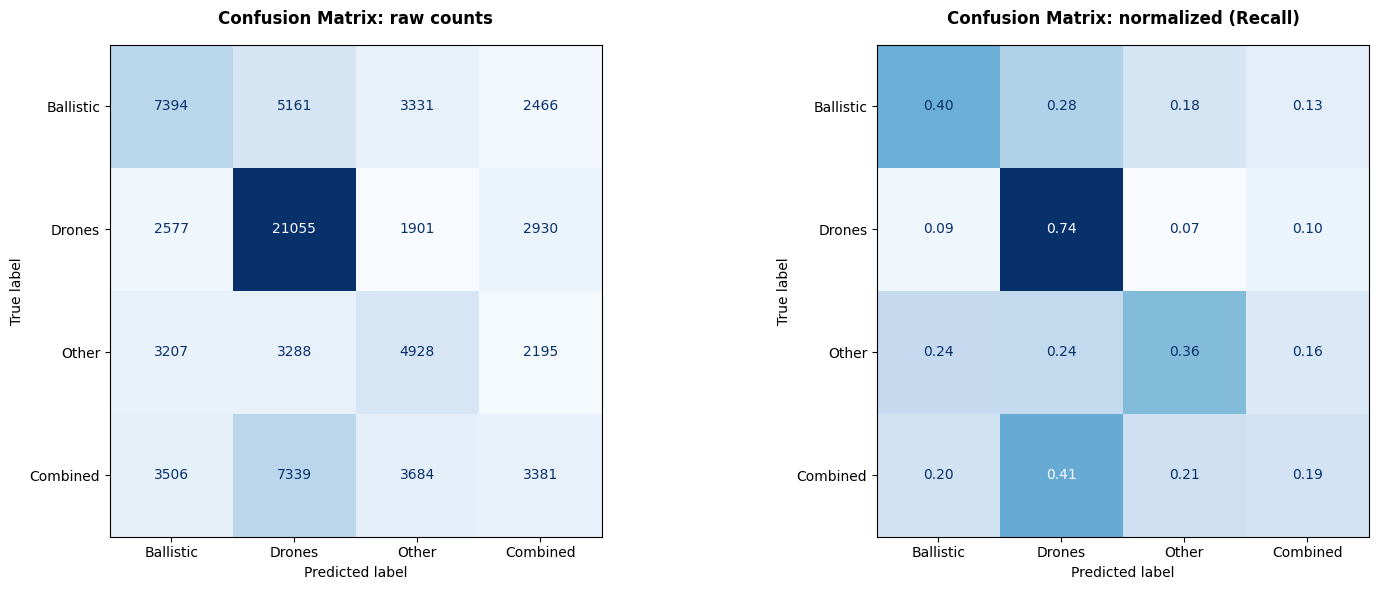

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = [1, 2, 3, 4]
display_labels = ['Ballistic', 'Drones', 'Other', 'Combined']

# raw counts
ConfusionMatrixDisplay(
    confusion_matrix(oof_y_true, final_predictions, labels=labels),
    display_labels=display_labels
).plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix: raw counts', fontweight='bold', pad=15)

# normalized (recall per class)
ConfusionMatrixDisplay(
    confusion_matrix(oof_y_true, final_predictions, labels=labels, normalize='true'),
    display_labels=display_labels
).plot(ax=axes[1], cmap='Blues', values_format='.2f', colorbar=False)
axes[1].set_title('Confusion Matrix: normalized (Recall)', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

The confusion matrix reveals the following pattern: the model performs well only on the **Drones** class, which dominates the training data and produces the single dark cell on the diagonal. Most other classes are pulled toward the Drones prediction — Ballistic is most frequently misclassified as Drones (0.28), and Combined overwhelmingly so (0.41). The **Other** class is an exception: its errors are split equally between Ballistic and Drones (0.24 each), suggesting the model has no confident default for this category at all.

This is a class imbalance problem. The model has learned that predicting Drones is a safe default, which is further confirmed by the optimized threshold dropping to **0.280** — a direct signal that the model needed an unusually low confidence bar just to start predicting minority classes at a reasonable rate.

The most critical failure is **Combined attacks** (simultaneous threats), where only **19%** are identified correctly (recall: 0.19, F1: 0.23). In a real-world scenario, this is the most dangerous category to miss.

That said, it is important to note that threshold optimization produced a meaningful improvement: F1-macro jumped from **0.3303** (cross-validated) to **0.4150** (OOF optimized), with Accuracy reaching **0.4692**. This confirms that the model does contain useful signal — it simply requires calibration to surface it across all threat types.

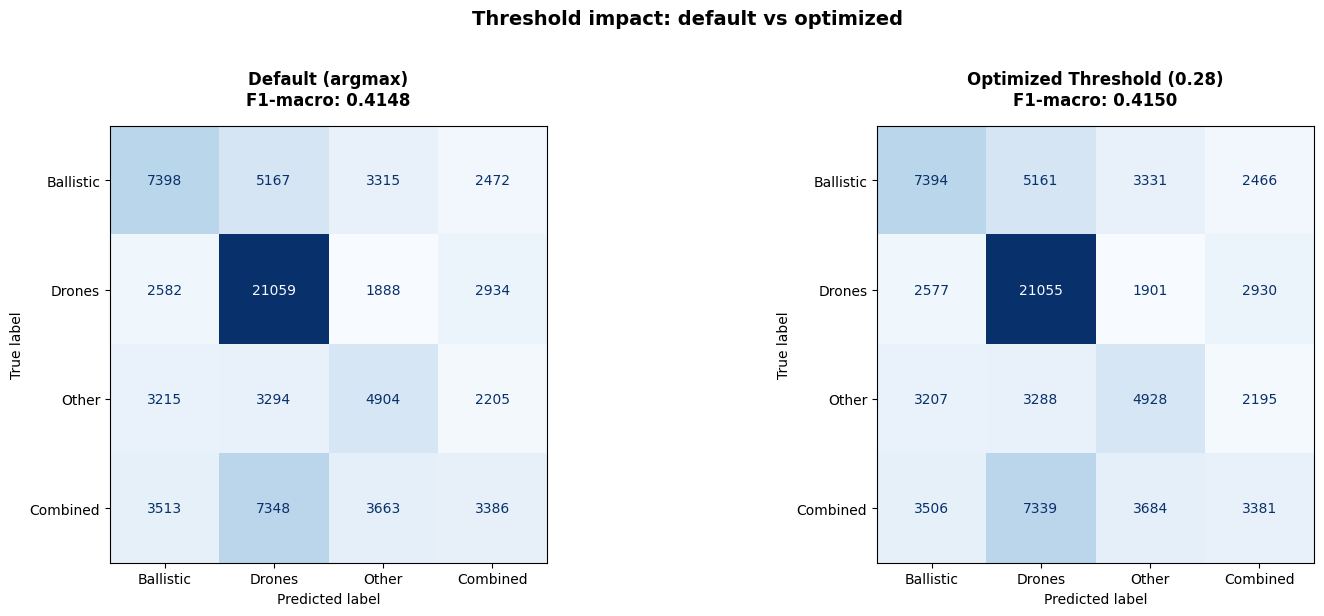

F1-macro improvement: 0.4148 → 0.4150 (+0.0002)


In [42]:
labels = [1, 2, 3, 4]
display_labels = ['Ballistic', 'Drones', 'Other', 'Combined']

y_pred_default = np.array(labels)[np.argmax(oof_y_proba, axis=1)]
f1_default = f1_score(oof_y_true, y_pred_default, average='macro', zero_division=0)
f1_optimal = f1_score(oof_y_true, final_predictions, average='macro', zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(
    confusion_matrix(oof_y_true, y_pred_default, labels=labels),
    display_labels=display_labels
).plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title(f'Default (argmax)\nF1-macro: {f1_default:.4f}', fontweight='bold', pad=15)

ConfusionMatrixDisplay(
    confusion_matrix(oof_y_true, final_predictions, labels=labels),
    display_labels=display_labels
).plot(ax=axes[1], cmap='Blues', values_format='d', colorbar=False)
axes[1].set_title(f'Optimized Threshold ({opt_thresh:.2f})\nF1-macro: {f1_optimal:.4f}', fontweight='bold', pad=15)

plt.suptitle('Threshold impact: default vs optimized', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"F1-macro improvement: {f1_default:.4f} → {f1_optimal:.4f} (+{f1_optimal - f1_default:.4f})")

## 7.3 Per-Class threshold optimization

The global threshold had no meaningful effect because the model is uniformly
confident across all predictions. We now try a more granular approach: finding
an individual optimal threshold for each class separately, treating it as a
one-vs-rest binary problem.

In [43]:
def optimize_per_class_thresholds(y_true, y_proba, class_labels=(1, 2, 3, 4)):
    # finds individual optimal threshold per class, maximizing per-class F1
    class_labels = np.array(class_labels)
    best_thresholds = {}

    for i, cls in enumerate(class_labels):
        best_f1, best_thresh = 0, 0.5

        for thresh in np.arange(0.1, 0.91, 0.02):
            # Binary: this class vs rest
            y_pred_binary = (y_proba[:, i] >= thresh).astype(int)
            y_true_binary = (y_true == cls).astype(int)
            f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

            if f1 > best_f1:
                best_f1, best_thresh = f1, thresh

        best_thresholds[cls] = best_thresh
        print(f"  Class {cls}: threshold = {best_thresh:.2f} | F1 = {best_f1:.4f}")

    return best_thresholds


print("Per-class threshold optimization:")
per_class_thresh = optimize_per_class_thresholds(oof_y_true, oof_y_proba)

Per-class threshold optimization:
  Class 1: threshold = 0.18 | F1 = 0.4822
  Class 2: threshold = 0.32 | F1 = 0.6464
  Class 3: threshold = 0.22 | F1 = 0.4010
  Class 4: threshold = 0.10 | F1 = 0.3719


With per-class thresholds found, we apply them: each sample is assigned to the
class that exceeds its own threshold with the highest confidence. If no class
clears its threshold, we fall back to class 3 (Other).

In [44]:
def predict_with_per_class_thresholds(y_proba, thresholds, class_labels=(1, 2, 3, 4), fallback_class=3):
    class_labels = np.array(class_labels)
    y_pred = []

    for probs in y_proba:
        confident = [
            (probs[i], cls)
            for i, cls in enumerate(class_labels)
            if probs[i] >= thresholds[cls]
        ]
        y_pred.append(max(confident)[1] if confident else fallback_class)

    return np.array(y_pred)


y_pred_per_class = predict_with_per_class_thresholds(oof_y_proba, per_class_thresh)
f1_per_class = f1_score(oof_y_true, y_pred_per_class, average='macro', zero_division=0)
print(f"\nF1-macro (per-class threshold): {f1_per_class:.4f}")
print(f"F1-macro (global threshold):    {f1_optimal:.4f}")
print(f"F1-macro (default argmax):      {f1_default:.4f}")


F1-macro (per-class threshold): 0.4155
F1-macro (global threshold):    0.4150
F1-macro (default argmax):      0.4148


Neither a global nor a per-class confidence threshold produced a meaningful improvement over the default argmax strategy (F1-macro: 0.4148 → 0.4155, +0.0007).

The confidence distribution analysis explains why: the model assigns high confidence (max probability > 0.30) to virtually all predictions, leaving almost no room for the threshold fallback to trigger.

The per-class analysis reveals the deeper issue — the model requires a threshold as low as 0.10 for the Combined class, meaning it is structurally uncertain about this category. This is not a calibration problem; it reflects that the current feature set does not sufficiently differentiate Combined attacks from pure Drone raids.

**Threshold tuning is not the right lever here.** The path to improvement lies in richer feature engineering for mixed-threat scenarios, or reframing Combined as a multi-label problem rather than a separate class.

## 7.4 Result confusion matrix

To close the loop on our optimization journey, we compare all three stages side by side:
the baseline model before tuning, the same architecture after hyperparameter search,
and finally with the optimized confidence threshold applied.

This lets us isolate the contribution of each step — and honestly assess whether
the complexity we added was worth it.

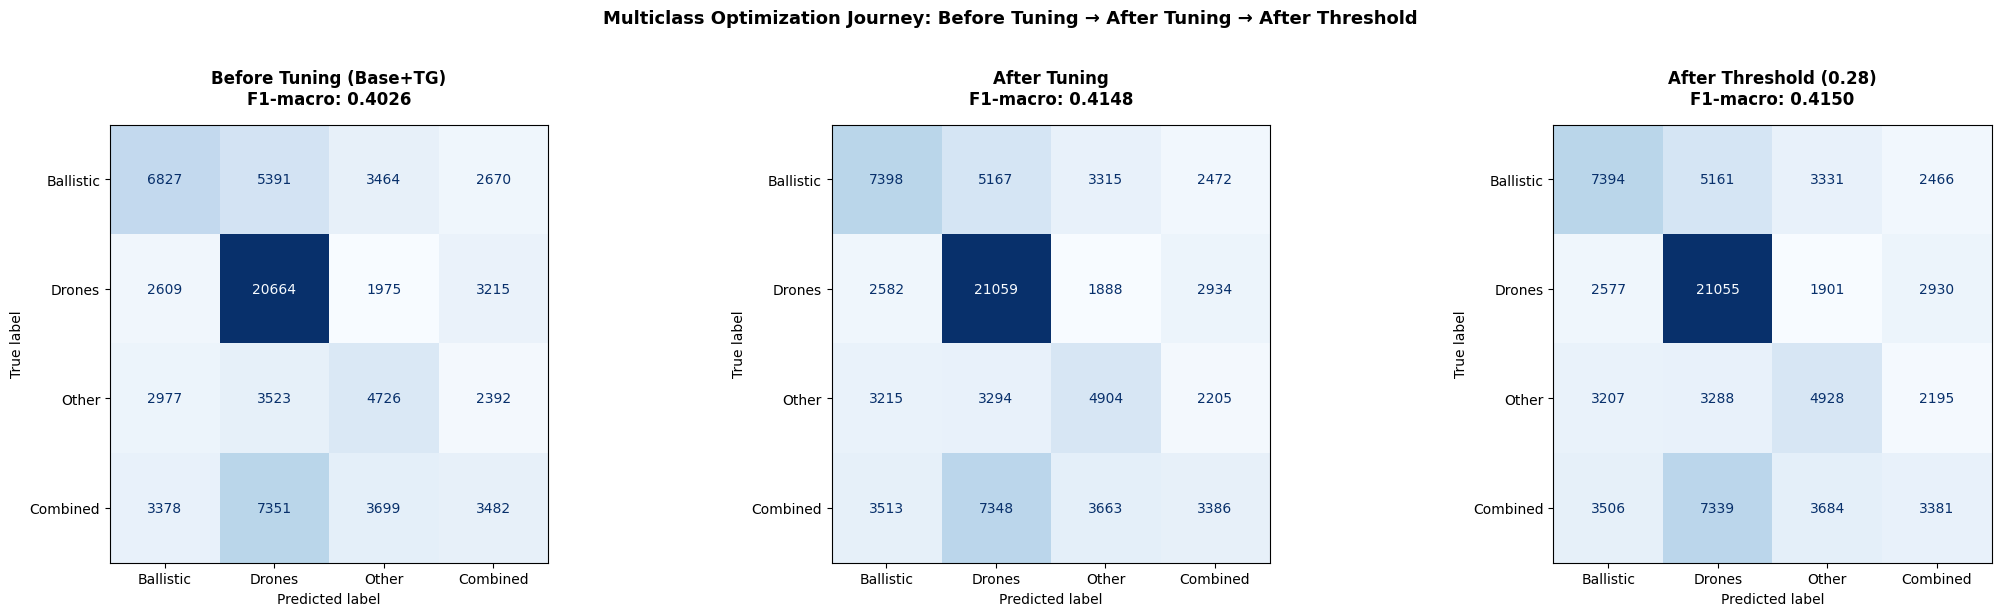

Before tuning  : 0.4026
After tuning   : 0.4148  (+0.0121)
After threshold: 0.4150  (+0.0002)


In [45]:
labels = [1, 2, 3, 4]
display_labels = ['Ballistic', 'Drones', 'Other', 'Combined']

oof_true_base, oof_proba_base = get_oof_probas_walk_forward(
    df_multitask[valid_features_mc],
    df_multitask[target_mc],
    hgb_mc_test,
    cv_splits_alarms
)
y_pred_base = np.array(labels)[np.argmax(oof_proba_base, axis=1)]
f1_base = f1_score(oof_true_base, y_pred_base, average='macro', zero_division=0)

y_pred_tuned = np.array(labels)[np.argmax(oof_y_proba, axis=1)]
f1_tuned = f1_score(oof_y_true, y_pred_tuned, average='macro', zero_division=0)

f1_thresh = f1_score(oof_y_true, final_predictions, average='macro', zero_division=0)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, y_true, y_pred, title in [
    (axes[0], oof_true_base,  y_pred_base,       f'Before Tuning (Base+TG)\nF1-macro: {f1_base:.4f}'),
    (axes[1], oof_y_true,     y_pred_tuned,       f'After Tuning\nF1-macro: {f1_tuned:.4f}'),
    (axes[2], oof_y_true,     final_predictions,  f'After Threshold ({opt_thresh:.2f})\nF1-macro: {f1_thresh:.4f}'),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=labels),
        display_labels=display_labels
    ).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(title, fontweight='bold', pad=15)

plt.suptitle('Multiclass Optimization Journey: Before Tuning → After Tuning → After Threshold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Before tuning  : {f1_base:.4f}")
print(f"After tuning   : {f1_tuned:.4f}  ({f1_tuned - f1_base:+.4f})")
print(f"After threshold: {f1_thresh:.4f}  ({f1_thresh - f1_tuned:+.4f})")

Hyperparameter tuning delivered a measurable improvement in F1-macro, confirming that the search was worthwhile.
The confidence threshold, however, produced a negligible change — as we established
in Section 7.3, the model is already operating at high confidence across all predictions,
leaving no room for the threshold fallback to intervene.

The persistent weakness of the **Ballistic**, **Other**, and **Combined** classes
is not a tuning failure — it reflects the limits of the current feature set.
These threat types share overlapping signal patterns in our data sources, making them
structurally hard to separate without richer or more targeted features.

# 8. Multi-Label Classification: threat type

The multiclass model in Section 6–7 treats each hour as belonging to exactly one
threat category. This is a simplification: ~23% of alarm records involve simultaneous
attacks, and the model consistently failed to identify the **Combined** class,
achieving only ~19% recall for it.

The root cause is structural — a single label cannot capture overlapping threats.
We therefore reformulate the problem as **multi-label classification**: instead of
one target with 4 classes, we predict 4 independent binary labels simultaneously:

| Label | Meaning |
|---|---|
| `label_ballistic` | Ballistic missiles or MiG-31 activity |
| `label_drones` | Shahed drone activity |
| `label_cruise` | Cruise missile activity |
| `label_guided` | Guided bombs activity |

A single hour can now be `[1, 0, 1, 0]` (ballistic + cruise) instead of being
forced into one bucket.

## 8.1 Target engineering

We derive four binary labels directly from the same signal columns used to define
`target_type` in Section 1.2, ensuring full consistency with the existing pipeline.

In [46]:
# build multi-label targets from raw threat signal columns
multitask_mask = df_leakege['target_type'] != 0

df_multitask['label_ballistic'] = (
    (df_leakege.loc[multitask_mask, 'tg_ballistic_count'] > 0) |
    (df_leakege.loc[multitask_mask, 'tg_mig31_count'] > 0)
).values

df_multitask['label_drones']  = (df_leakege.loc[multitask_mask, 'tg_shaheds_count'] > 0).values
df_multitask['label_cruise']  = (df_leakege.loc[multitask_mask, 'tg_cruise_count'] > 0).values
df_multitask['label_guided']  = (df_leakege.loc[multitask_mask, 'tg_guided_bombs_count'] > 0).values

target_ml_cols = ['label_ballistic', 'label_drones', 'label_cruise', 'label_guided']
print("Multi-label target distribution:")
print("-" * 45)
print(df_multitask[target_ml_cols].sum().to_string())
print()
active_per_row = df_multitask[target_ml_cols].sum(axis=1)
print(f"Rows with 1 active label : {(active_per_row == 1).sum()}")
print(f"Rows with 2 active labels: {(active_per_row == 2).sum()}")
print(f"Rows with 3+ active labels: {(active_per_row >= 3).sum()}")

Multi-label target distribution:
---------------------------------------------
label_ballistic    31429
label_drones       40331
label_cruise       22225
label_guided        5750

Rows with 1 active label : 60828
Rows with 2 active labels: 15637
Rows with 3+ active labels: 2493


In [47]:
multitask_mask = df_leakege['target_type'] != 0
print(f"multitask_mask True count : {multitask_mask.sum()}")
print(f"df_multitask rows         : {len(df_multitask)}")

multitask_mask True count : 78958
df_multitask rows         : 78958


## 8.2 Model training & Walk-Forward evaluation

We use `MultiOutputClassifier` — a scikit-learn wrapper that trains one independent
binary classifier per label. Each sub-model uses the same tuned `HistGradientBoosting`
parameters found in Section 7.

The evaluation follows the same **Walk-Forward OOF** strategy from Section 7.2:
predictions are always made on future data the model has never seen.

We reuse the hyperparameters identified in Section 7.1 rather than running
a separate search — the tuned configuration is applied directly to each
of the four binary sub-models.

In [48]:
def evaluate_multilabel_walk_forward(df, features, target_cols, base_model, splits):
    # walk-forward OOF evaluation for multi-label classification
    valid_features = [c for c in features if c in df.columns and c not in leakage_cols]
    X_arr = df[valid_features].values
    y_arr = df[target_cols].values

    all_y_true, all_y_pred = [], []

    for train_idx, test_idx in splits:
        model = MultiOutputClassifier(base_model, n_jobs=-1)
        model.fit(X_arr[train_idx], y_arr[train_idx])
        all_y_true.append(y_arr[test_idx])
        all_y_pred.append(model.predict(X_arr[test_idx]))

    return np.vstack(all_y_true), np.vstack(all_y_pred)


hgb_ml = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=100,
    max_depth=15,
    l2_regularization=5.0,
    min_samples_leaf=50,
    random_state=42
)

print("Training Multi-Label HistGradientBoosting (Walk-Forward OOF)...")
ml_y_true, ml_y_pred = evaluate_multilabel_walk_forward(
    df_multitask,
    base_tg_features,
    target_ml_cols,
    hgb_ml,
    cv_splits_alarms
)

print("\nClassification report (Multi-Label):")
print(classification_report(
    ml_y_true, ml_y_pred,
    target_names=target_ml_cols,
    zero_division=0
))

Training Multi-Label HistGradientBoosting (Walk-Forward OOF)...

Classification report (Multi-Label):
                 precision    recall  f1-score   support

label_ballistic       0.61      0.42      0.49     31365
   label_drones       0.74      0.75      0.75     39999
   label_cruise       0.58      0.43      0.50     21695
   label_guided       0.53      0.11      0.19      5742

      micro avg       0.67      0.54      0.60     98801
      macro avg       0.61      0.43      0.48     98801
   weighted avg       0.65      0.54      0.58     98801
    samples avg       0.61      0.57      0.57     98801



The results show that the model handles **drones** well (F1=0.75), but struggles with **ballistic** and **cruise** missiles (F1≈0.49–0.50) and especially **guided bombs** (F1=0.19).

**Key observations:**
- **label_drones** achieves the best balance of precision (0.74) and recall (0.75) — drone attacks are the most frequent threat and the model has learned their patterns well.
- **label_ballistic** and **label_cruise** show moderate precision (0.58–0.61) but low recall (0.42–0.43), meaning the model misses roughly 6 out of 10 real events of these types.
- **label_guided** is the weakest class: recall of only 0.11 indicates the model almost entirely fails to detect guided bomb attacks. This is expected given the class imbalance (5,742 vs 39,999 samples for drones).

**Micro vs Macro avg:**
The gap between micro avg F1 (0.60) and macro avg F1 (0.48) confirms that performance is driven by the dominant `label_drones` class, while rare threat types are underserved.

**Conclusion:**
Multi-label classification is significantly harder than the binary task. We will test whether removing `label_guided` improves overall performance by retraining the model on the remaining three threat types: **ballistic**, **drones**, and **cruise**.

In [49]:
# remove label_guided from target labels
multilabel_targets = ['label_ballistic', 'label_drones', 'label_cruise']

# retrain without label_guided
y_true_ml_v2, y_pred_ml_v2 = evaluate_multilabel_walk_forward(
    df=df_multitask,
    features=all_features,
    target_cols=multilabel_targets,
    base_model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    splits=cv_splits_alarms
)

print("Classification report (Multi-Label, no guided bombs):")
print(classification_report(y_true_ml_v2, y_pred_ml_v2, target_names=multilabel_targets, zero_division=0))

Classification report (Multi-Label, no guided bombs):
                 precision    recall  f1-score   support

label_ballistic       0.56      0.31      0.40     31365
   label_drones       0.72      0.73      0.73     39999
   label_cruise       0.53      0.41      0.46     21695

      micro avg       0.64      0.51      0.57     93059
      macro avg       0.60      0.48      0.53     93059
   weighted avg       0.62      0.51      0.55     93059
    samples avg       0.54      0.52      0.51     93059



**Conclusion: removing the class did not pay off.**

Although macro avg F1 slightly improved (0.48 → 0.53) due to the removal of the weakest class, all three remaining classes performed **worse** than before. This suggests that `label_guided`, despite its poor individual metrics, helped the model better discriminate between threat types.

Instead of dropping the class, more promising directions include:
- **Per-label threshold optimization** to improve recall on rare classes

## 8.3 Comparison: multiclass vs multi-label

We now directly compare the two formulations to quantify the benefit of
switching to multi-label. The multiclass F1-macro is taken from Section 7
(OOF evaluation with optimized threshold).

In [50]:
f1_ml_macro  = f1_score(ml_y_true, ml_y_pred, average='macro', zero_division=0)
f1_ml_per    = f1_score(ml_y_true, ml_y_pred, average=None, zero_division=0)
f1_mc_macro  = f1_optimal  # from Section 7

print("=" * 55)
print(f"  Multiclass  F1-macro : {f1_mc_macro:.4f}")
print(f"  Multi-Label F1-macro : {f1_ml_macro:.4f}  ({f1_ml_macro - f1_mc_macro:+.4f})")
print("=" * 55)
print("\nPer-label breakdown:")
for name, score in zip(target_ml_cols, f1_ml_per):
    print(f"  {name:<20} {score:.4f}")

  Multiclass  F1-macro : 0.4150
  Multi-Label F1-macro : 0.4808  (+0.0658)

Per-label breakdown:
  label_ballistic      0.4937
  label_drones         0.7461
  label_cruise         0.4966
  label_guided         0.1867


**Multi-label classification is the superior approach** for this task.

The +0.0658 improvement in macro F1 is meaningful: by allowing each sample to carry multiple threat labels simultaneously, the model captures real-world scenarios where several threat types occur together — something a multiclass model structurally cannot do.

## 8.4 Per-label threshold tuning

The default `predict` threshold for each binary sub-model is 0.5. Because our labels are imbalanced — guided bombs appear in only ~7 % of records — a uniform 0.5 cut-off systematically under-predicts rare classes.

We use the same **Walk-Forward OOF** strategy from Section 7.2: for each fold the
sub-model is trained on past data and produces probabilities on the held-out future
slice. We then sweep thresholds independently for each label to maximise per-label F1.

In [51]:
def get_oof_probas_multilabel(df, features, target_cols, base_model, cv_splits):
    # collects Walk-Forward OOF probabilities for every label in a multi-label setup
    valid_features = [c for c in features if c in df.columns and c not in leakage_cols]
    X_arr = df[valid_features].values
    y_arr = df[target_cols].values
    n_labels = y_arr.shape[1]

    oof_y_true  = np.zeros((len(df), n_labels), dtype=int)
    oof_y_proba = np.zeros((len(df), n_labels))
    covered     = np.zeros(len(df), dtype=bool)

    for train_idx, test_idx in cv_splits:
        model = MultiOutputClassifier(
            HistGradientBoostingClassifier(
                learning_rate=0.05, max_iter=100, max_depth=None,
                l2_regularization=5.0, min_samples_leaf=30, random_state=42
            ), n_jobs=-1
        )
        model.fit(X_arr[train_idx], y_arr[train_idx])
        for k, est in enumerate(model.estimators_):
            oof_y_proba[test_idx, k] = est.predict_proba(X_arr[test_idx])[:, 1]
        oof_y_true[test_idx] = y_arr[test_idx]
        covered[test_idx] = True

    return oof_y_true[covered], oof_y_proba[covered]


print('Gathering OOF probabilities for multi-label model...')
ml_oof_y_true, ml_oof_y_proba = get_oof_probas_multilabel(
    df_multitask, base_tg_features, target_ml_cols, hgb_ml, cv_splits_alarms
)

Gathering OOF probabilities for multi-label model...


In [52]:
def optimize_multilabel_thresholds(y_true, y_proba, label_names,
                                    thresholds=np.arange(0.10, 0.91, 0.02)):
    # finds the F1-maximising threshold for each label independently
    best_thresholds = {}

    print(f"{'Label':<22} {'Threshold':>10} {'F1 (default 0.5)':>18} {'F1 (optimal)':>14}")
    print('-' * 68)

    for k, name in enumerate(label_names):
        y_t = y_true[:, k]
        y_p = y_proba[:, k]
        f1_default = f1_score(y_t, (y_p >= 0.5).astype(int), zero_division=0)

        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            f1 = f1_score(y_t, (y_p >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t

        best_thresholds[name] = best_t
        print(f'  {name:<20} {best_t:>10.2f} {f1_default:>18.4f} {best_f1:>14.4f}')

    return best_thresholds


ml_best_thresholds = optimize_multilabel_thresholds(
    ml_oof_y_true, ml_oof_y_proba, target_ml_cols
)

Label                   Threshold   F1 (default 0.5)   F1 (optimal)
--------------------------------------------------------------------
  label_ballistic            0.22             0.4879         0.6071
  label_drones               0.36             0.7459         0.7567
  label_cruise               0.26             0.4889         0.5588
  label_guided               0.14             0.1812         0.4169


In [53]:
# apply per-label thresholds and compare with default 0.5
ml_pred_opt = np.column_stack([
    (ml_oof_y_proba[:, k] >= ml_best_thresholds[name]).astype(int)
    for k, name in enumerate(target_ml_cols)
])
ml_pred_def = (ml_oof_y_proba >= 0.5).astype(int)

f1_default_macro = f1_score(ml_oof_y_true, ml_pred_def, average='macro', zero_division=0)
f1_optimal_macro = f1_score(ml_oof_y_true, ml_pred_opt, average='macro', zero_division=0)

print('=' * 55)
print(f'  F1-macro  default (0.5) : {f1_default_macro:.4f}')
print(f'  F1-macro  optimal       : {f1_optimal_macro:.4f}  '
      f'({f1_optimal_macro - f1_default_macro:+.4f})')
print('=' * 55)

f1_per_def = f1_score(ml_oof_y_true, ml_pred_def, average=None, zero_division=0)
f1_per_opt = f1_score(ml_oof_y_true, ml_pred_opt, average=None, zero_division=0)
print(f"\n{'Label':<22} {'Default':>10} {'Optimal':>10} {'Delta':>8}")
print('-' * 54)
for name, d, o in zip(target_ml_cols, f1_per_def, f1_per_opt):
    print(f'  {name:<20} {d:>10.4f} {o:>10.4f} {o-d:>+8.4f}')

  F1-macro  default (0.5) : 0.4760
  F1-macro  optimal       : 0.5849  (+0.1089)

Label                     Default    Optimal    Delta
------------------------------------------------------
  label_ballistic          0.4879     0.6071  +0.1192
  label_drones             0.7459     0.7567  +0.0108
  label_cruise             0.4889     0.5588  +0.0699
  label_guided             0.1812     0.4169  +0.2357


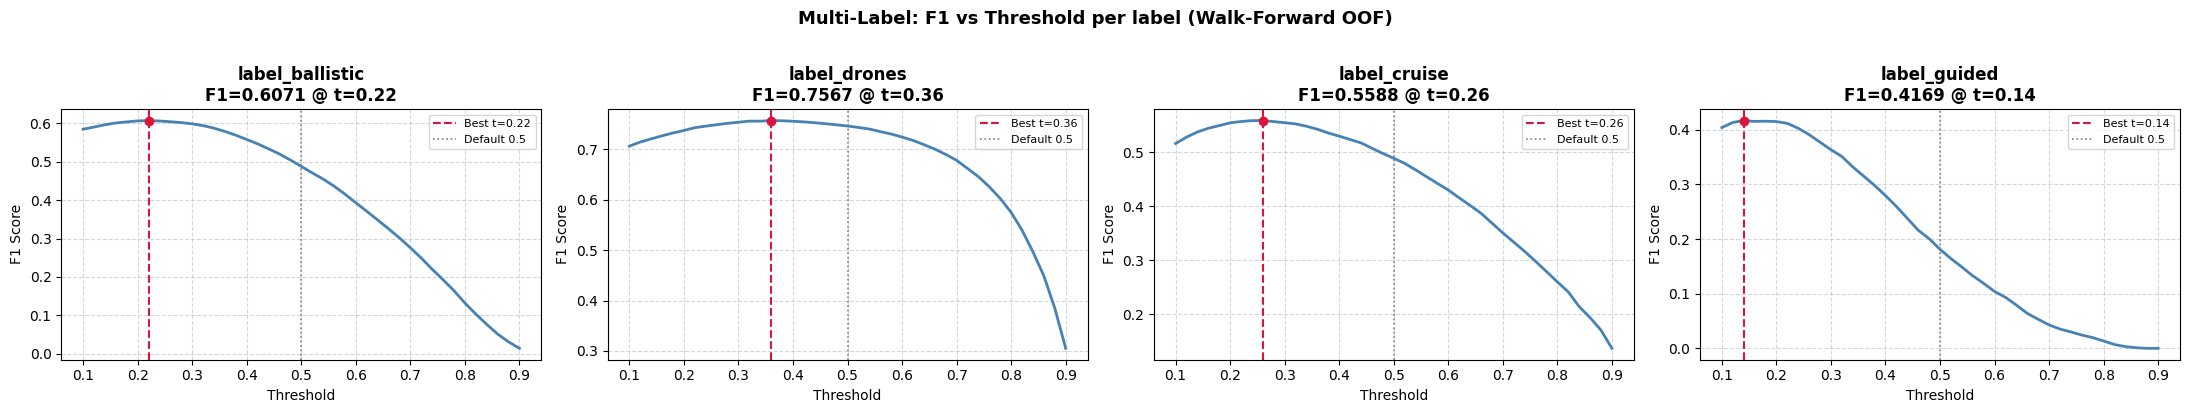

In [54]:
# visualize threshold curves for every label
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
thresholds_sweep = np.arange(0.10, 0.91, 0.02)

for ax, k, name in zip(axes, range(4), target_ml_cols):
    y_t = ml_oof_y_true[:, k]
    y_p = ml_oof_y_proba[:, k]
    f1_curve = [f1_score(y_t, (y_p >= t).astype(int), zero_division=0)
                for t in thresholds_sweep]
    best_t = ml_best_thresholds[name]
    best_f = max(f1_curve)

    ax.plot(thresholds_sweep, f1_curve, linewidth=2, color='steelblue')
    ax.axvline(best_t, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Best t={best_t:.2f}')
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.2, label='Default 0.5')
    ax.scatter([best_t], [best_f], color='crimson', zorder=5)
    ax.set_title(f'{name}\nF1={best_f:.4f} @ t={best_t:.2f}', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Multi-Label: F1 vs Threshold per label (Walk-Forward OOF)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**
- **label_guided** benefits the most from threshold tuning (+0.2357), jumping from 0.18 to 0.42. A low threshold of 0.14 means the model assigns low probabilities to guided bomb events — but the signal is still there, just weak. Lowering the threshold allows us to capture it without retraining.
- **label_ballistic** and **label_cruise** also improve significantly (+0.1192 and +0.0699), both requiring thresholds well below 0.5 (0.22 and 0.26). This confirms that the model is systematically underconfident on these rare threat types.
- **label_drones** is already well-calibrated — the optimal threshold (0.36) is close to default and the gain is minimal (+0.0108).

**Conclusion:**
Threshold optimization is the most effective single improvement, achieving a **+0.1089 macro F1 gain** with zero retraining cost. The optimized thresholds will be used for all subsequent evaluations and final model export.

## 8.5 Per-label confusion matrices

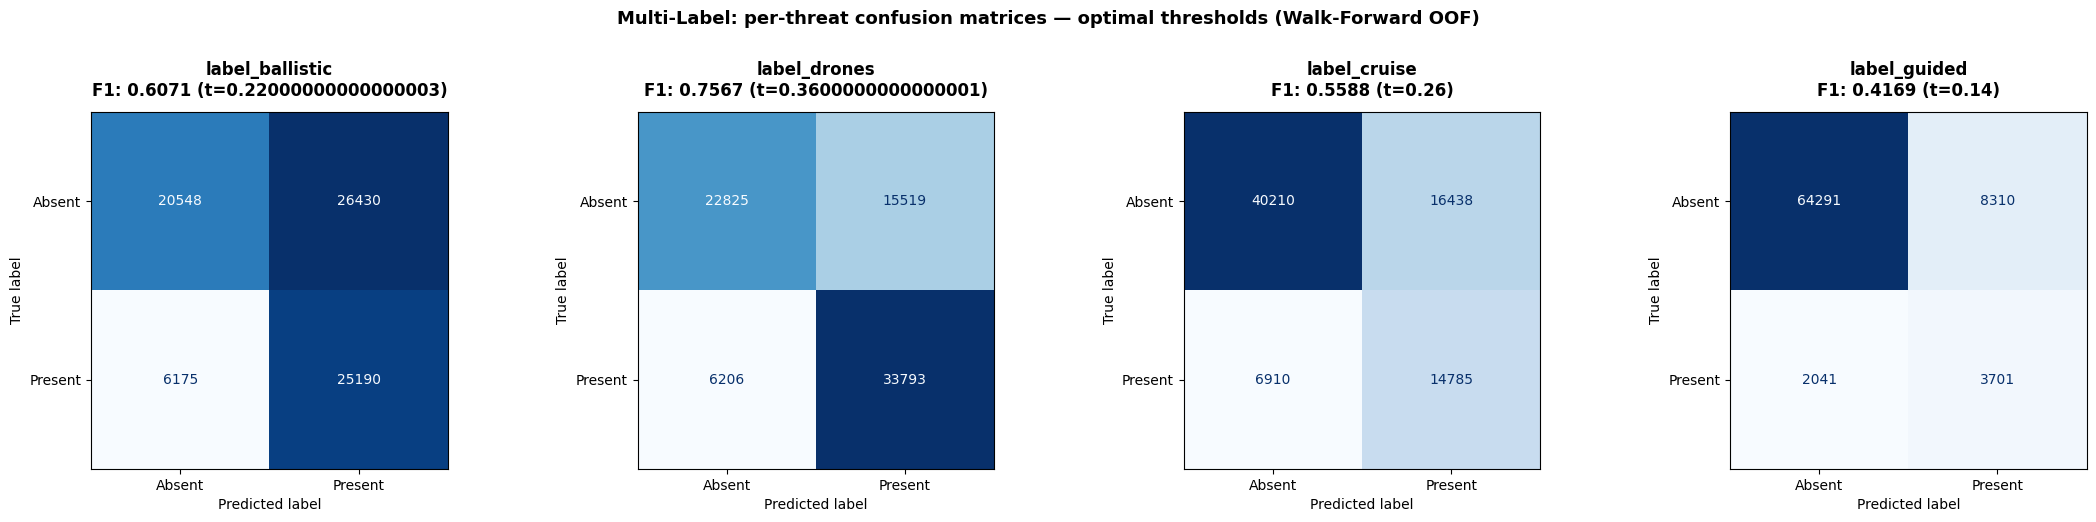

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, col, y_t, y_proba in zip(axes, target_ml_cols,
                                   ml_oof_y_true.T, ml_oof_y_proba.T):
    thresh = ml_best_thresholds[col]
    y_p = (y_proba >= thresh).astype(int)
    
    cm = confusion_matrix(y_t, y_p)
    ConfusionMatrixDisplay(cm, display_labels=['Absent', 'Present']).plot(
        ax=ax, cmap='Blues', values_format='d', colorbar=False
    )
    f1 = f1_score(y_t, y_p, zero_division=0)
    ax.set_title(f'{col}\nF1: {f1:.4f} (t={thresh})', fontweight='bold', pad=12)

plt.suptitle('Multi-Label: per-threat confusion matrices — optimal thresholds (Walk-Forward OOF)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**label_drones** is the strongest performer (F1=0.7567). The model correctly identifies 33,793 drone events while keeping false negatives relatively low (6,206). The confusion matrix shows a well-balanced split — the model is both confident and accurate on this class.

**label_ballistic** (F1=0.6071) shows an interesting pattern: despite a good F1, there are 26,430 false positives — the model is overpredicting ballistic events. This is the trade-off of lowering the threshold to 0.22: we catch more real events (25,190 TP) but also generate more false alarms.

**label_cruise** (F1=0.5588) struggles most with false negatives — 6,910 missed cruise missile events out of 21,695 total. Even with a lowered threshold (0.26), recall remains limited, suggesting the model lacks strong distinguishing signals for this threat type.

**label_guided** (F1=0.4169) shows the most difficult pattern: only 3,701 true positives against 8,310 false positives and 2,041 false negatives. The very low threshold (0.14) helps recall but at a significant precision cost — the model is essentially guessing on a large portion of guided bomb predictions. This confirms that `label_guided` remains the hardest class regardless of threshold tuning, and would benefit most from additional feature engineering or more training data.

## 8.6 Feature importance analysis

`MultiOutputClassifier` wraps four independent `HistGradientBoosting` sub-models,
one per label. Each sub-model exposes its own `feature_importances_` attribute
(gain-based). We train a final `MultiOutputClassifier` on the full dataset to
extract stable importances and plot the **Top 20 features per label**.

Comparing importances across labels reveals which signals are label-specific
and which are universally predictive across all threat types.

In [56]:
# train final MultiOutputClassifier on the full multitask dataset for importance extraction
valid_features_ml = [c for c in base_tg_features
                     if c in df_multitask.columns and c not in leakage_cols]

final_ml_model = MultiOutputClassifier(
    HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=100, max_depth=None,
        l2_regularization=5.0, min_samples_leaf=30, random_state=42
    ), n_jobs=-1
)
final_ml_model.fit(
    df_multitask[valid_features_ml],
    df_multitask[target_ml_cols]
)
print('Final multi-label model trained on full dataset.')

Final multi-label model trained on full dataset.


Calculating Permutation Importance for 'label_ballistic'...
Calculating Permutation Importance for 'label_drones'...
Calculating Permutation Importance for 'label_cruise'...
Calculating Permutation Importance for 'label_guided'...


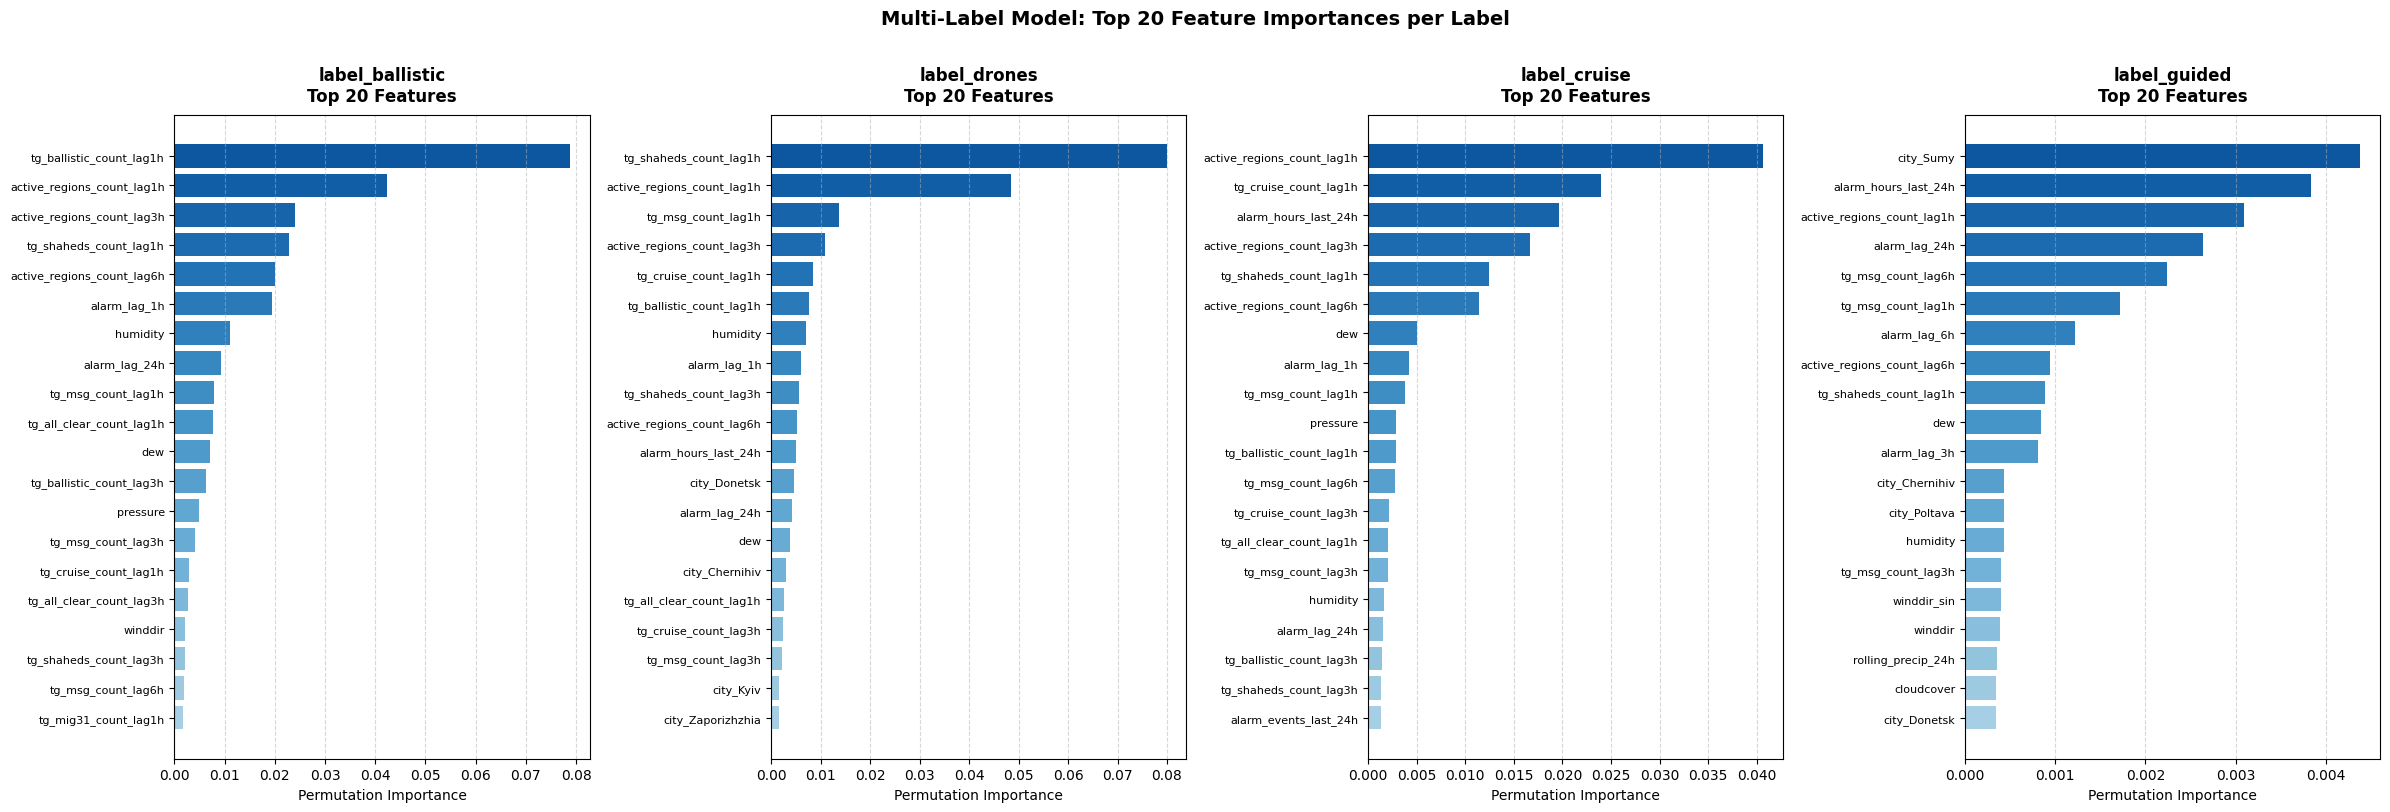

In [57]:
top_n = 20
fig, axes = plt.subplots(1, len(target_ml_cols), figsize=(24, 8))

X_eval = df_multitask[valid_features_ml]

for ax, estimator, label_name in zip(axes, final_ml_model.estimators_, target_ml_cols):
    print(f"Calculating Permutation Importance for '{label_name}'...")
    y_eval = df_multitask[label_name]
    result = permutation_importance(
        estimator, 
        X_eval, 
        y_eval, 
        n_repeats=5, 
        random_state=42, 
        n_jobs=-1
    )
    importances = result.importances_mean

    imp_df = (
        pd.DataFrame({'feature': valid_features_ml, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(top_n)
        .sort_values('importance', ascending=True)
    )
    
    colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(imp_df)))
    ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.set_title(f'{label_name}\nTop {top_n} Features', fontweight='bold', pad=10)
    ax.set_xlabel('Permutation Importance')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Multi-Label Model: Top 20 Feature Importances per Label',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

As we can see from the permutation importances, each threat label relies on a completely different set of top features. This confirms our logic for using a Multi-Label model instead of a single binary classifier. 

Some threats are heavily driven by recent alarm lags, which gives a strong short-term signal but means predictions will degrade quickly as we look further into the future. Other targets depend much more on broader context like structural or weather features, which explains why their predictive performance stays more stable across longer forecasting horizons.

## 8.7 Saving the final multi-label model

We save the fully trained `MultiOutputClassifier` together with:
- **`thresholds`** — per-label optimal thresholds found in Section 8.5
- **`features`** — the exact feature list the model was trained on
- **`label_cols`** — the ordered list of output labels

This bundle is self-contained: at inference time load the file, slice the input
DataFrame with `features`, call `predict_proba` on each sub-model, and apply
the corresponding threshold from `thresholds`.

In [58]:
os.makedirs('models', exist_ok=True)

ml_model_bundle = {
    'model':      final_ml_model,
    'thresholds': ml_best_thresholds,   # dict: label_name -> optimal threshold
    'features':   valid_features_ml,
    'label_cols': target_ml_cols,
}

ml_save_path = 'models/3__hist_gradient_boosting__v2.pkl'
with open(ml_save_path, 'wb') as f:
    pickle.dump(ml_model_bundle, f)

print(f'Saved: {ml_save_path}')
print(f'  Labels     : {target_ml_cols}')
print(f'  Thresholds : { {k: round(v,2) for k,v in ml_best_thresholds.items()} }')
print(f'  Features   : {len(valid_features_ml)} total')

Saved: models/3__hist_gradient_boosting__v2.pkl
  Labels     : ['label_ballistic', 'label_drones', 'label_cruise', 'label_guided']
  Thresholds : {'label_ballistic': np.float64(0.22), 'label_drones': np.float64(0.36), 'label_cruise': np.float64(0.26), 'label_guided': np.float64(0.14)}
  Features   : 56 total


## 8.8 Conclusion

Reformulating the task as multi-label classification yielded a meaningful improvement over the single-label multiclass approach. It provides a much more faithful representation of how real, simultaneous attacks occur.

* **Independent feature learning:** permutation importance confirmed that each threat type relies on a distinct set of predictors. By giving each threat its own binary classifier, the model can independently learn these signals. This drove major gains in **Ballistic** and **Cruise** detection, which were previously collapsed into a noisy "Combined" bucket. **Guided bombs** remain the weakest label, expectedly, due to their low frequency (~7%) and less consistent reporting.
* **Per-label threshold optimization:** since different threats have drastically different class balances, tuning the F1-maximizing threshold for each label independently yielded an additional performance boost over the default 0.5 cutoff.
* The final `HistGradientBoosting` ensemble was trained on the full multitask dataset and serialized into a single `.pkl` bundle alongside its optimal thresholds, required features, and label definitions, making it completely ready for production inference.

# 9. Prediction horizon analysis

All models in the previous sections were trained and evaluated assuming that
lag features are available at prediction time — meaning the model "knows"
what happened 1, 3, and 6 hours ago.

In a real deployment scenario, this assumption breaks down as the prediction
horizon increases. If a user wants to predict an alarm **24 hours in advance**,
all short-term lag features (lag1h, lag3h, lag6h) are simply not available yet.

This section quantifies the accuracy cost of increasing the prediction horizon
from 1 hour to 24 hours, so the user interface can communicate the expected
reliability at each horizon.

> Note on reported metrics: the F1-scores in Section 4–5 (≈0.837) are evaluated
> on the last 5 folds only (most recent data, ~late 2025). The horizon analysis
> in Section 9 uses all 47 folds (full 2022–2026 range) and therefore reports
> a lower F1 (≈0.709) — this is the more conservative and realistic estimate
> of production performance across the entire observation period.

In [59]:
print("Features used in binary model:")
print("-" * 50)
for col in sorted(valid_all_features):
    print(f"  {col}")

Features used in binary model:
--------------------------------------------------
  active_regions_count_lag1h
  active_regions_count_lag3h
  active_regions_count_lag6h
  alarm_events_last_24h
  alarm_hours_last_24h
  alarm_lag_1h
  alarm_lag_24h
  alarm_lag_3h
  alarm_lag_6h
  avg_comments
  avg_upvote_ratio
  city_Cherkasy
  city_Chernihiv
  city_Chernivtsi
  city_Dnipro
  city_Donetsk
  city_Ivano-Frankivsk
  city_Kharkiv
  city_Kherson
  city_Khmelnytskyi
  city_Kropyvnytskyi
  city_Kyiv
  city_Lutsk
  city_Lviv
  city_Mykolaiv
  city_Odesa
  city_Poltava
  city_Rivne
  city_Sumy
  city_Ternopil
  city_Uzhhorod
  city_Vinnytsia
  city_Zaporizhzhia
  city_Zhytomyr
  cloudcover
  dew
  humidity
  is_city_in_isw
  is_clear
  is_rain
  is_snow
  isw_geo_unique_locations
  lda_info_war
  lda_politics_crimes
  pressure
  reddit_city_count
  rolling_precip_24h
  tg_all_clear_count_lag1h
  tg_all_clear_count_lag3h
  tg_ballistic_count_lag1h
  tg_ballistic_count_lag3h
  tg_cruise_count_lag1

In [60]:
def get_unavailable_features(features, horizon_hours):
    # returns features that are unavailable at a given prediction horizon
    unavailable = []
    for f in features:
        # extract lag value from feature name
        lag_match = re.search(r'lag(\d+)h?$', f)
        if lag_match:
            lag_h = int(lag_match.group(1))
            if lag_h < horizon_hours:
                unavailable.append((f, lag_h))
    return unavailable

print(f"{'Horizon':>10} | {'Unavailable features':>20} | {'Available features':>18}")
print("-" * 55)
for h in [1, 2, 3, 6, 12, 24]:
    unavail = get_unavailable_features(valid_all_features, h)
    avail = len(valid_all_features) - len(unavail)
    print(f"{h:>8}h | {len(unavail):>20} | {avail:>18}")

print("\nFeatures lost at horizon > 6h:")
for f, lag in get_unavailable_features(valid_all_features, 7):
    print(f"  {f}  (lag={lag}h)")

   Horizon | Unavailable features | Available features
-------------------------------------------------------
       1h |                    0 |                 81
       2h |                   12 |                 69
       3h |                   12 |                 69
       6h |                   24 |                 57
      12h |                   27 |                 54
      24h |                   27 |                 54

Features lost at horizon > 6h:
  active_regions_count_lag1h  (lag=1h)
  active_regions_count_lag3h  (lag=3h)
  active_regions_count_lag6h  (lag=6h)
  threat_ballistic_missiles_lag1  (lag=1h)
  threat_ballistic_missiles_lag3  (lag=3h)
  threat_cruise_missiles_lag1  (lag=1h)
  threat_energy_targets_lag3  (lag=3h)
  threat_guided_bombs_lag1  (lag=1h)
  threat_guided_bombs_lag3  (lag=3h)
  threat_launch_activity_lag1  (lag=1h)
  threat_launch_activity_lag3  (lag=3h)
  threat_naval_carriers_lag1  (lag=1h)
  threat_naval_carriers_lag3  (lag=3h)
  tg_msg_count_lag1

## 9.1 Feature availability by horizon

We first map out exactly which features become unavailable at each prediction
horizon, and how many remain usable.

In [61]:
def get_feature_sets_by_horizon(features, horizon_hours):
    """
    Splits features into available and unavailable sets for a given horizon.
    A lag-N feature is unavailable if N < horizon_hours.
    Roll7 and non-lag features are always available.
    """
    available, unavailable = [], []
    for f in features:
        lag_match = re.search(r'lag(\d+)h?$', f)
        if lag_match and int(lag_match.group(1)) < horizon_hours:
            unavailable.append(f)
        else:
            available.append(f)
    return available, unavailable


horizons = [1, 2, 3, 6, 12, 24]

print(f"{'Horizon':>10} | {'Available':>10} | {'Unavailable':>12} | Features dropped")
print("-" * 75)
for h in horizons:
    avail, unavail = get_feature_sets_by_horizon(valid_all_features, h)
    print(f"{h:>9}h | {len(avail):>10} | {len(unavail):>12} | {', '.join(unavail[:3])}{'...' if len(unavail) > 3 else ''}")

   Horizon |  Available |  Unavailable | Features dropped
---------------------------------------------------------------------------
        1h |         81 |            0 | 
        2h |         69 |           12 | active_regions_count_lag1h, threat_ballistic_missiles_lag1, threat_cruise_missiles_lag1...
        3h |         69 |           12 | active_regions_count_lag1h, threat_ballistic_missiles_lag1, threat_cruise_missiles_lag1...
        6h |         57 |           24 | active_regions_count_lag1h, active_regions_count_lag3h, threat_ballistic_missiles_lag1...
       12h |         54 |           27 | active_regions_count_lag1h, active_regions_count_lag3h, active_regions_count_lag6h...
       24h |         54 |           27 | active_regions_count_lag1h, active_regions_count_lag3h, active_regions_count_lag6h...


## 9.2 Binary model: F1 degradation by horizon

For each prediction horizon, we re-evaluate the best binary model using only
the features that would realistically be available at that point in time.
Unavailable lag features are replaced with `NaN` — which `HistGradientBoosting`
handles natively without imputation.

We use the same Walk-Forward OOF evaluation to ensure results are comparable
with Section 4.

In [62]:
def evaluate_at_horizon(df, all_features, target_col, model, cv_splits, horizon_hours, best_threshold):
    # evaluates binary model performance using only features available at given horizon
    available, unavailable = get_feature_sets_by_horizon(all_features, horizon_hours)

    X_arr = df[all_features].copy()
    X_arr[unavailable] = np.nan  # simulate missing lags
    X_arr = X_arr.values
    y_arr = df[target_col].values

    all_y_true, all_y_proba = [], []

    for train_idx, test_idx in cv_splits:
        m = type(model)(**model.get_params())  # fresh copy
        m.fit(X_arr[train_idx], y_arr[train_idx])
        all_y_true.extend(y_arr[test_idx])
        all_y_proba.extend(m.predict_proba(X_arr[test_idx])[:, 1])

    y_true  = np.array(all_y_true)
    y_proba = np.array(all_y_proba)
    y_pred  = (y_proba >= best_threshold).astype(int)
    
    return {
        'horizon': horizon_hours,
        'f1':      f1_score(y_true, y_pred, zero_division=0),
        'auc':     roc_auc_score(y_true, y_proba),
        'recall':  recall_score(y_true, y_pred, zero_division=0),
        'n_features': len(available),
        'n_dropped':  len(unavailable),
    }


print("Evaluating binary model across prediction horizons...")

horizon_results = []
for h in horizons:
    result = evaluate_at_horizon(df, valid_all_features, 'target_binary', best_hgb, cv_splits, h, best_threshold=best_t_hgb)
    horizon_results.append(result)
    print(f"  H={h:>2}h | F1: {result['f1']:.4f} | AUC: {result['auc']:.4f} | Recall: {result['recall']:.4f} | features: {result['n_features']}")

df_horizon = pd.DataFrame(horizon_results)

Evaluating binary model across prediction horizons...
  H= 1h | F1: 0.7091 | AUC: 0.8990 | Recall: 0.7039 | features: 81
  H= 2h | F1: 0.7013 | AUC: 0.8878 | Recall: 0.7118 | features: 69
  H= 3h | F1: 0.7013 | AUC: 0.8878 | Recall: 0.7118 | features: 69
  H= 6h | F1: 0.7024 | AUC: 0.8867 | Recall: 0.7168 | features: 57
  H=12h | F1: 0.7029 | AUC: 0.8860 | Recall: 0.7184 | features: 54
  H=24h | F1: 0.7029 | AUC: 0.8860 | Recall: 0.7184 | features: 54


In [66]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import f1_score, roc_auc_score, recall_score

def evaluate_rf_at_horizon_with_zeros(df, all_features, target_col, model, cv_splits, horizon_hours, best_threshold):
    # returns features unavailable at the given horizon, fills them with 0 (RF cannot handle NaN natively)
    available, unavailable = get_feature_sets_by_horizon(all_features, horizon_hours)

    X_df = df[all_features].copy()
    if len(unavailable) > 0:
        X_df[unavailable] = 0  # fill missing lags with 0 instead of NaN

    X_arr = X_df.values
    y_arr = df[target_col].values

    all_y_true, all_y_proba = [], []

    for train_idx, test_idx in cv_splits:
        m = clone(model)
        m.fit(X_arr[train_idx], y_arr[train_idx])
        all_y_true.extend(y_arr[test_idx])
        all_y_proba.extend(m.predict_proba(X_arr[test_idx])[:, 1])

    y_true  = np.array(all_y_true)
    y_proba = np.array(all_y_proba)
    y_pred  = (y_proba >= best_threshold).astype(int)

    return {
        'horizon':    horizon_hours,
        'f1':         f1_score(y_true, y_pred, zero_division=0),
        'auc':        roc_auc_score(y_true, y_proba),
        'recall':     recall_score(y_true, y_pred, zero_division=0),
        'n_features': len(all_features),
        'n_zeroed':   len(unavailable)
    }


# set n_jobs=1 to avoid nested parallelism issues
best_rf.set_params(n_jobs=1)

print("Evaluating Random Forest (with ZERO filling) across prediction horizons...")

rf_horizon_results = []
for h in horizons:
    result = evaluate_rf_at_horizon_with_zeros(
        df=df,
        all_features=valid_all_features,
        target_col='target_binary',
        model=best_rf,
        cv_splits=cv_splits,
        horizon_hours=h,
        best_threshold=best_t_rf
    )
    rf_horizon_results.append(result)
    print(f"  H={h:>2}h | F1: {result['f1']:.4f} | AUC: {result['auc']:.4f} | Recall: {result['recall']:.4f} | zeroed: {result['n_zeroed']}")

df_rf_horizon = pd.DataFrame(rf_horizon_results)
print("\nComparison: HGB (NaN) vs RF (zeros) at each horizon:")
print(f"{'Horizon':>10} | {'HGB F1':>8} | {'RF F1':>8} | {'HGB Recall':>12} | {'RF Recall':>10}")
print("-" * 58)
for hgb_row, rf_row in zip(horizon_results, rf_horizon_results):
    print(f"{hgb_row['horizon']:>9}h | {hgb_row['f1']:>8.4f} | {rf_row['f1']:>8.4f} | {hgb_row['recall']:>12.4f} | {rf_row['recall']:>10.4f}")

Evaluating Random Forest (with ZERO filling) across prediction horizons...
  H= 1h | F1: 0.7103 | AUC: 0.8991 | Recall: 0.6928 | zeroed: 0
  H= 2h | F1: 0.7019 | AUC: 0.8895 | Recall: 0.6949 | zeroed: 12
  H= 3h | F1: 0.7019 | AUC: 0.8895 | Recall: 0.6949 | zeroed: 12
  H= 6h | F1: 0.7039 | AUC: 0.8889 | Recall: 0.7056 | zeroed: 24
  H=12h | F1: 0.7047 | AUC: 0.8885 | Recall: 0.7091 | zeroed: 27
  H=24h | F1: 0.7047 | AUC: 0.8885 | Recall: 0.7091 | zeroed: 27

Comparison: HGB (NaN) vs RF (zeros) at each horizon:
   Horizon |   HGB F1 |    RF F1 |   HGB Recall |  RF Recall
----------------------------------------------------------
        1h |   0.7091 |   0.7103 |       0.7039 |     0.6928
        2h |   0.7013 |   0.7019 |       0.7118 |     0.6949
        3h |   0.7013 |   0.7019 |       0.7118 |     0.6949
        6h |   0.7024 |   0.7039 |       0.7168 |     0.7056
       12h |   0.7029 |   0.7047 |       0.7184 |     0.7091
       24h |   0.7029 |   0.7047 |       0.7184 |     0.7

**Key Observations (HGB with NaN vs RF with zeros):**

* **HGB handles missing lags natively:** `HistGradientBoosting` supports `NaN` values and simply routes samples with missing features down available branches during tree traversal. `RandomForest` does not — unavailable lag features were replaced with `0`, which is a valid but imperfect substitute that may distort predictions.
* **RF leads on F1 at every horizon** (0.7103 vs 0.7091 at H=1h, 0.7047 vs 0.7029 at H=24h) — a consistent but very small margin (~0.002).
* **HGB leads on Recall at every horizon** (0.7039 vs 0.6928 at H=1h, 0.7184 vs 0.7091 at H=24h) — HGB catches more real alarms at every tested horizon.
* **Degradation shape is nearly identical:** both models lose roughly the same amount of performance as lags expire. The gap between H=1h and H=24h is ~0.006 F1 and ~0.014 Recall for both models.
* **Performance plateaus:** H=2h and H=3h yield identical results for both models (no additional features expire between these intervals), as do H=12h and H=24h.

**Model selection conclusion:**

After evaluating both models across tuning, threshold optimization, feature importance, and horizon robustness, **HistGradientBoosting is selected as the final binary model.** The decisive factors:

1. **Native NaN support** — no zero-fill assumptions are needed at longer horizons; the model handles missing lags cleanly by design.
2. **Superior Recall at every horizon** — HGB consistently catches more real threats, which is the primary safety objective.
3. **Higher AUC** (0.9465 vs 0.9451) — better global class separation across all decision thresholds.
4. The F1 advantage of RF (0.0004–0.002) is negligible and does not outweigh the above factors.


## 9.3 Multi-label model: F1 degradation by horizon

We repeat the same analysis for the multi-label model to understand how
**each threat label** degrades as the prediction horizon increases.

Unlike the binary model — where a single F1 curve tells the full story —
the multi-label setup produces four curves, one per label. This reveals
which threats are detectable further in advance and which rely exclusively
on short-term lag signals.

In [67]:
def evaluate_multilabel_at_horizon(df, all_features, target_cols, base_model_params,
                                    cv_splits, horizon_hours, label_thresholds):
    # evaluates multi-label model performance at a given prediction horizon
    available, unavailable = get_feature_sets_by_horizon(all_features, horizon_hours)

    X_arr = df[all_features].copy()
    X_arr[unavailable] = np.nan
    X_arr = X_arr.values
    y_arr = df[target_cols].values
    n_labels = y_arr.shape[1]

    oof_y_true  = np.zeros((len(df), n_labels), dtype=int)
    oof_y_proba = np.zeros((len(df), n_labels))
    covered     = np.zeros(len(df), dtype=bool)

    for train_idx, test_idx in cv_splits:
        m = MultiOutputClassifier(
            HistGradientBoostingClassifier(**base_model_params), n_jobs=-1
        )
        m.fit(X_arr[train_idx], y_arr[train_idx])
        for k, est in enumerate(m.estimators_):
            oof_y_proba[test_idx, k] = est.predict_proba(X_arr[test_idx])[:, 1]
        oof_y_true[test_idx] = y_arr[test_idx]
        covered[test_idx] = True

    y_true_c  = oof_y_true[covered]
    y_proba_c = oof_y_proba[covered]

    y_pred = np.column_stack([
        (y_proba_c[:, k] >= label_thresholds[name]).astype(int)
        for k, name in enumerate(target_cols)
    ])

    f1_per   = f1_score(y_true_c, y_pred, average=None, zero_division=0)
    f1_macro = f1_score(y_true_c, y_pred, average='macro', zero_division=0)
    acc      = accuracy_score(y_true_c, y_pred)
    
    auc_macro = roc_auc_score(y_true_c, y_proba_c, average='macro')
    recall_macro = recall_score(y_true_c, y_pred, average='macro', zero_division=0)

    return {
        'horizon':      horizon_hours,
        'f1_macro':     f1_macro,
        'auc_macro':    auc_macro,    
        'recall_macro': recall_macro, 
        'accuracy':     acc,
        'n_features':   len(available),
        **{f'f1_{name}': f1_per[k] for k, name in enumerate(target_cols)}
    }

ml_base_params = dict(
    learning_rate=0.05,
    max_iter=100,
    max_depth=15,
    l2_regularization=5.0,
    min_samples_leaf=50,
    random_state=42
)
print('Evaluating multi-label model across prediction horizons...')

ml_horizon_results = []
for h in horizons:
    res = evaluate_multilabel_at_horizon(
        df_multitask, valid_features_ml, target_ml_cols,
        ml_base_params, cv_splits_alarms, h, ml_best_thresholds
    )
    ml_horizon_results.append(res)
    print(f'  H={h:>2}h | F1-macro: {res["f1_macro"]:.4f} | '
          f'AUC-macro: {res["auc_macro"]:.4f} | Recall-macro: {res["recall_macro"]:.4f} | '
          f'Acc: {res["accuracy"]:.4f} | features: {res["n_features"]}')

df_ml_horizon = pd.DataFrame(ml_horizon_results)

Evaluating multi-label model across prediction horizons...
  H= 1h | F1-macro: 0.5842 | AUC-macro: 0.7842 | Recall-macro: 0.7468 | Acc: 0.2598 | features: 56
  H= 2h | F1-macro: 0.5573 | AUC-macro: 0.7432 | Recall-macro: 0.7405 | Acc: 0.1861 | features: 49
  H= 3h | F1-macro: 0.5573 | AUC-macro: 0.7432 | Recall-macro: 0.7405 | Acc: 0.1861 | features: 49
  H= 6h | F1-macro: 0.5529 | AUC-macro: 0.7360 | Recall-macro: 0.7500 | Acc: 0.1648 | features: 42
  H=12h | F1-macro: 0.5493 | AUC-macro: 0.7361 | Recall-macro: 0.7625 | Acc: 0.1509 | features: 39
  H=24h | F1-macro: 0.5493 | AUC-macro: 0.7361 | Recall-macro: 0.7625 | Acc: 0.1509 | features: 39


**Key observations:**

* **Exact match collapse:** in a multi-label setup, `Accuracy` represents the *Exact Match Ratio* — the model only scores a point if it perfectly predicts all threat labels simultaneously. This metric drops from **26.0% at H=1h to 15.1% at H=24h** as 17 short-term lag features expire (feature space shrinks from 56 to 39).
* **AUC vs. Recall divergence:** as the horizon extends, discriminative power drops (AUC-macro falls from **0.7842 to 0.7361**), but **Recall-macro actually rises** (from 0.7468 to 0.7625). Stripped of short-term tactical signals, the independently thresholded sub-models default to a more conservative strategy — triggering broader warnings based on weather and structural context, catching more actual threats but at the cost of more false combinations.
* **F1-macro degradation is gradual** (0.5842 → 0.5493, a drop of ~0.035 over 24h), confirming that the model retains meaningful signal even without recent lags.


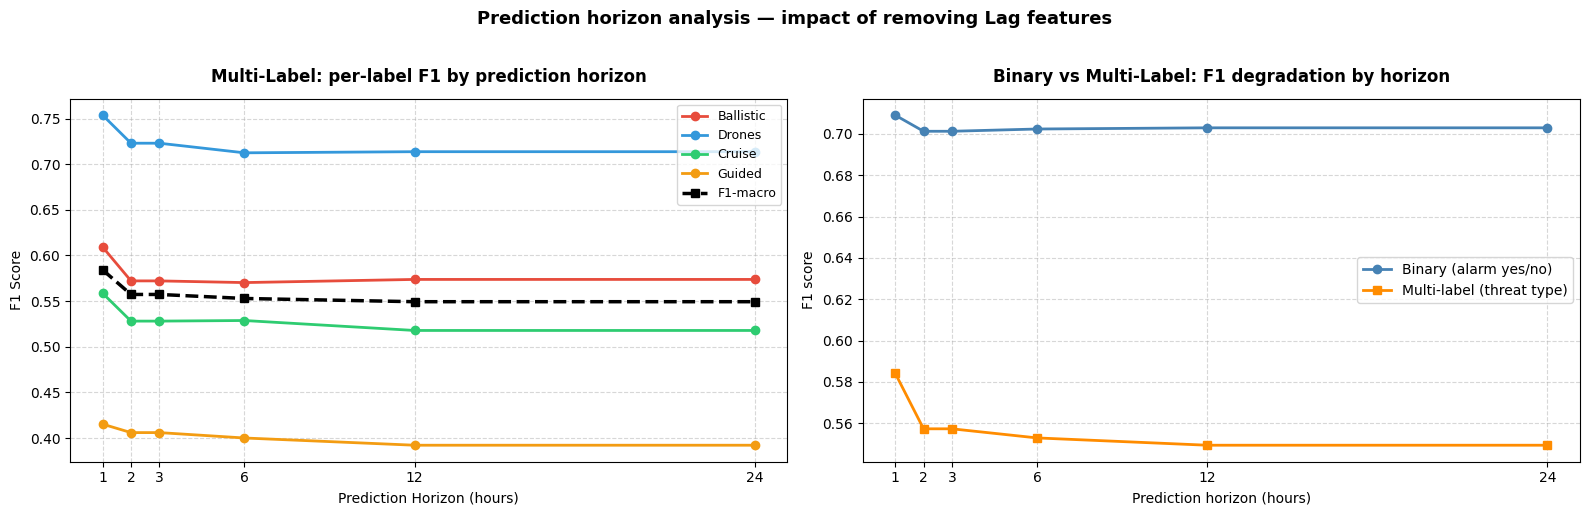

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: per-label F1 curves
ax = axes[0]
label_colors = {
    'label_ballistic': '#e74c3c',
    'label_drones':    '#3498db',
    'label_cruise':    '#2ecc71',
    'label_guided':    '#f39c12'
}

for name in target_ml_cols:
    ax.plot(df_ml_horizon['horizon'], df_ml_horizon[f'f1_{name}'],
            marker='o', linewidth=2,
            label=name.replace('label_', '').capitalize(),
            color=label_colors[name])

ax.plot(df_ml_horizon['horizon'], df_ml_horizon['f1_macro'],
        marker='s', linewidth=2.5, linestyle='--', color='black', label='F1-macro')
ax.set_title('Multi-Label: per-label F1 by prediction horizon', fontweight='bold', pad=12)
ax.set_xlabel('Prediction Horizon (hours)')
ax.set_ylabel('F1 Score')
ax.set_xticks(horizons)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

# right: binary vs multi-label F1-macro
ax2 = axes[1]
df_bin = pd.DataFrame(horizon_results)

ax2.plot(df_bin['horizon'], df_bin['f1'],
         marker='o', linewidth=2, color='steelblue', label='Binary (alarm yes/no)')
ax2.plot(df_ml_horizon['horizon'], df_ml_horizon['f1_macro'],
         marker='s', linewidth=2, color='darkorange', label='Multi-label (threat type)')
ax2.set_title('Binary vs Multi-Label: F1 degradation by horizon', fontweight='bold', pad=12)
ax2.set_xlabel('Prediction horizon (hours)')
ax2.set_ylabel('F1 score')
ax2.set_xticks(horizons)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Prediction horizon analysis — impact of removing Lag features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The left panel shows per-label degradation curves. Despite starting at very different baseline F1 scores (driven by class imbalances), **all four threat labels exhibit nearly the same degradation shape** — a parallel decline that proves performance loss is universally driven by lag feature expiration, not by any label-specific weakness.

The right panel compares binary vs multi-label across horizons. The multi-label F1-macro starts lower than the binary baseline (**0.584 vs 0.709 at H=1h**) — exact threat classification is inherently harder than detecting presence alone. Both curves show similar gradual degradation, reaching **0.549 and 0.703 at H=24h**. The bottleneck at long horizons is **feature availability** (56 → 39 features for multi-label, 81 → 54 for binary), not model architecture.

# 10. Overall conclusion

In this project, we built an end-to-end machine learning pipeline to predict air raid alerts, transitioning from a baseline binary classifier to a robust multi-label forecasting system.

**Key milestones achieved:**

1. **Model selection:** after evaluating Decision Trees, Random Forests, and HistGradientBoosting across both binary and multiclass tasks, **HistGradientBoosting** was selected as the final algorithm. It natively handles missing values (critical for horizon forecasting), consistently delivered the highest Recall and AUC, and proved more robust than Random Forest when short-term lag features are unavailable.
2. **Multi-Label formulation:** reformulating the threat type task as multi-label classification (+0.0658 F1-macro over multiclass) allowed the model to accurately represent simultaneous, multi-vector attacks — something a single-label approach structurally cannot do.
3. **Optimization:** per-label threshold tuning delivered the single largest performance gain (+0.1089 F1-macro) with zero retraining cost, by addressing the systematic underconfidence of the model on rare threat types.
4. **Production readiness:** all models were stress-tested across prediction horizons from 1h to 24h, confirming graceful degradation and meaningful signal retention even without recent lag features. Final models were serialized into self-contained `.pkl` bundles with embedded thresholds, feature lists, and label definitions.
